In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Path to LOBSTER data
lobster_path = "D:/MSc/MLP/Sem 2/Project/LOBSTER Data/extracted/"

Using device: cuda


In [8]:
def load_lobster_orderbook(filepath):
    """Load LOBSTER orderbook and convert to FI-2010 format"""
    df = pd.read_csv(filepath, header=None)
    
    # LOBSTER: ask1_p, ask1_s, bid1_p, bid1_s, ask2_p, ask2_s, bid2_p, bid2_s, ...
    # FI-2010: ask1_p, ask1_s, ask2_p, ask2_s, ..., ask10_p, ask10_s, bid1_p, bid1_s, ..., bid10_p, bid10_s
    
    n_levels = 10
    ask_cols = []
    bid_cols = []
    
    for i in range(n_levels):
        ask_cols.extend([i*4, i*4+1])      # ask_price, ask_size
        bid_cols.extend([i*4+2, i*4+3])    # bid_price, bid_size
    
    # Reorder: all asks first, then all bids
    reordered = df.iloc[:, ask_cols + bid_cols].values
    
    return reordered

# Load all stocks
stocks = ['AAPL', 'AMZN', 'GOOG', 'INTC', 'MSFT']
lobster_data = {}

for stock in stocks:
    filepath = f"{lobster_path}{stock}_2012-06-21_34200000_57600000_orderbook_10.csv"
    lobster_data[stock] = load_lobster_orderbook(filepath)
    print(f"{stock}: {lobster_data[stock].shape}")

AAPL: (400391, 40)
AMZN: (269748, 40)
GOOG: (147916, 40)
INTC: (624040, 40)
MSFT: (668765, 40)


In [9]:
def normalize_lobster(data):
    """Z-score normalization per feature"""
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1  # avoid division by zero
    return (data - mean) / std

def create_labels(data, k=10):
    """Create mid-price movement labels (same as FI-2010)"""
    # Mid-price = (best_ask + best_bid) / 2
    # In FI-2010 format: col 0 = ask1_price, col 20 = bid1_price
    mid_price = (data[:, 0] + data[:, 20]) / 2
    
    labels = np.zeros(len(mid_price))
    
    for i in range(len(mid_price) - k):
        future_avg = np.mean(mid_price[i+1:i+k+1])
        current = mid_price[i]
        
        pct_change = (future_avg - current) / current
        
        # Threshold similar to FI-2010 (0.002 = 0.2%)
        if pct_change > 0.0002:
            labels[i] = 2  # up
        elif pct_change < -0.0002:
            labels[i] = 0  # down
        else:
            labels[i] = 1  # stationary
    
    return labels.astype(int)

# Process each stock
for stock in stocks:
    lobster_data[stock] = normalize_lobster(lobster_data[stock])
    
print("Normalization complete")
print(f"Sample mean (should be ~0): {lobster_data['AAPL'].mean():.6f}")
print(f"Sample std (should be ~1): {lobster_data['AAPL'].std():.6f}")

Normalization complete
Sample mean (should be ~0): -0.000000
Sample std (should be ~1): 1.000000


In [10]:
def prepare_sequences_subset(data, labels, T=100, max_samples=50000):
    """Create sequences - subset to avoid memory issues"""
    N = min(len(data) - T - 10, max_samples)
    
    X = np.zeros((N, T, 40), dtype=np.float32)
    y = np.zeros(N, dtype=np.int64)
    
    for i in range(N):
        X[i] = data[i:i+T]
        y[i] = labels[i+T]
    
    return X, y

# Evaluate AAPL (first 50k samples)
stock = 'AAPL'
labels = create_labels(lobster_data[stock], k=10)
X_test, y_test = prepare_sequences_subset(lobster_data[stock].astype(np.float32), labels, T=100, max_samples=50000)

print(f"{stock}: {X_test.shape[0]} samples")
print(f"Label distribution: {np.bincount(y_test)}")

AAPL: 50000 samples
Label distribution: [19198 10597 20205]


In [11]:
class deeplob(nn.Module):
    def __init__(self, y_len):
        super().__init__()
        self.y_len = y_len
        
        # convolution blocks
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,2), stride=(1,2)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.Tanh(),
            nn.BatchNorm2d(32),
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(1,10)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
            nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(4,1)),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(32),
        )
        
        # inception modules
        self.inp1 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(3,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=(5,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        self.inp3 = nn.Sequential(
            nn.MaxPool2d((3, 1), stride=(1, 1), padding=(1, 0)),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(1,1), padding='same'),
            nn.LeakyReLU(negative_slope=0.01),
            nn.BatchNorm2d(64),
        )
        
        # lstm layers
        self.lstm = nn.LSTM(input_size=192, hidden_size=64, num_layers=1, batch_first=True)
        self.fc1 = nn.Linear(64, self.y_len)

    def forward(self, x):
        h0 = torch.zeros(1, x.size(0), 64).to(device)
        c0 = torch.zeros(1, x.size(0), 64).to(device)
    
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        
        x_inp1 = self.inp1(x)
        x_inp2 = self.inp2(x)
        x_inp3 = self.inp3(x)  
        
        x = torch.cat((x_inp1, x_inp2, x_inp3), dim=1)
        
        x = x.permute(0, 2, 1, 3)
        x = torch.reshape(x, (-1, x.shape[1], x.shape[2]))
        
        x, _ = self.lstm(x, (h0, c0))
        x = x[:, -1, :]
        x = self.fc1(x)
        forecast_y = torch.softmax(x, dim=1)
        
        return forecast_y

# Load trained model
model = torch.load('jupyter_pytorch/best_val_model_pytorch', map_location=device)
model.to(device)
model.eval()

print("Model loaded successfully")

Model loaded successfully


C:\Users\Ash\AppData\Local\Temp\ipykernel_21404\3637503823.py:94: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('jupyter_pytorch/best_val_model_pytorch', 

In [12]:
# Create dataloader
dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_test).unsqueeze(1),
    torch.LongTensor(y_test)
)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

# Evaluate
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Results
print(f"LOBSTER ({stock}) - FI-2010 trained model:")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=['Down', 'Stationary', 'Up']))

LOBSTER (AAPL) - FI-2010 trained model:
Accuracy: 0.4030
              precision    recall  f1-score   support

        Down       0.38      0.24      0.29     19198
  Stationary       0.32      0.00      0.01     10597
          Up       0.41      0.77      0.53     20205

    accuracy                           0.40     50000
   macro avg       0.37      0.34      0.28     50000
weighted avg       0.38      0.40      0.33     50000



In [13]:
results = {'AAPL': {'acc': 0.4030, 'f1': 0.28}}

for stock in ['AMZN', 'GOOG', 'INTC', 'MSFT']:
    labels = create_labels(lobster_data[stock], k=10)
    X_test, y_test = prepare_sequences_subset(lobster_data[stock].astype(np.float32), labels, T=100, max_samples=50000)
    
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_test).unsqueeze(1),
        torch.LongTensor(y_test)
    )
    test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = classification_report(all_labels, all_preds, output_dict=True)['macro avg']['f1-score']
    results[stock] = {'acc': acc, 'f1': f1}
    print(f"{stock}: Accuracy={acc:.4f}, F1={f1:.4f}")

print("\n--- Summary ---")
for stock, res in results.items():
    print(f"{stock}: Acc={res['acc']:.2%}, F1={res['f1']:.2%}")

AMZN: Accuracy=0.2945, F1=0.2380
GOOG: Accuracy=0.3248, F1=0.2543
INTC: Accuracy=0.2768, F1=0.2015
MSFT: Accuracy=0.2979, F1=0.2070

--- Summary ---
AAPL: Acc=40.30%, F1=28.00%
AMZN: Acc=29.45%, F1=23.80%
GOOG: Acc=32.48%, F1=25.43%
INTC: Acc=27.68%, F1=20.15%
MSFT: Acc=29.79%, F1=20.70%


In [14]:
# Load raw FI-2010 data (before normalization)
fi_train = np.loadtxt('data/Train_Dst_NoAuction_DecPre_CF_7.txt')
fi_test1 = np.loadtxt('data/Test_Dst_NoAuction_DecPre_CF_7.txt')

# FI-2010 format: rows are features, columns are time -> transpose
fi_data = np.hstack([fi_train, fi_test1]).T
fi_lob = fi_data[:, :40]  # First 40 columns are LOB data

print(f"FI-2010 shape: {fi_lob.shape}")

# Reload raw LOBSTER (before normalization)
lobster_raw = {}
for stock in stocks:
    filepath = f"{lobster_path}{stock}_2012-06-21_34200000_57600000_orderbook_10.csv"
    lobster_raw[stock] = load_lobster_orderbook(filepath)
    
print(f"LOBSTER AAPL shape: {lobster_raw['AAPL'].shape}")

FI-2010 shape: (310228, 40)
LOBSTER AAPL shape: (400391, 40)


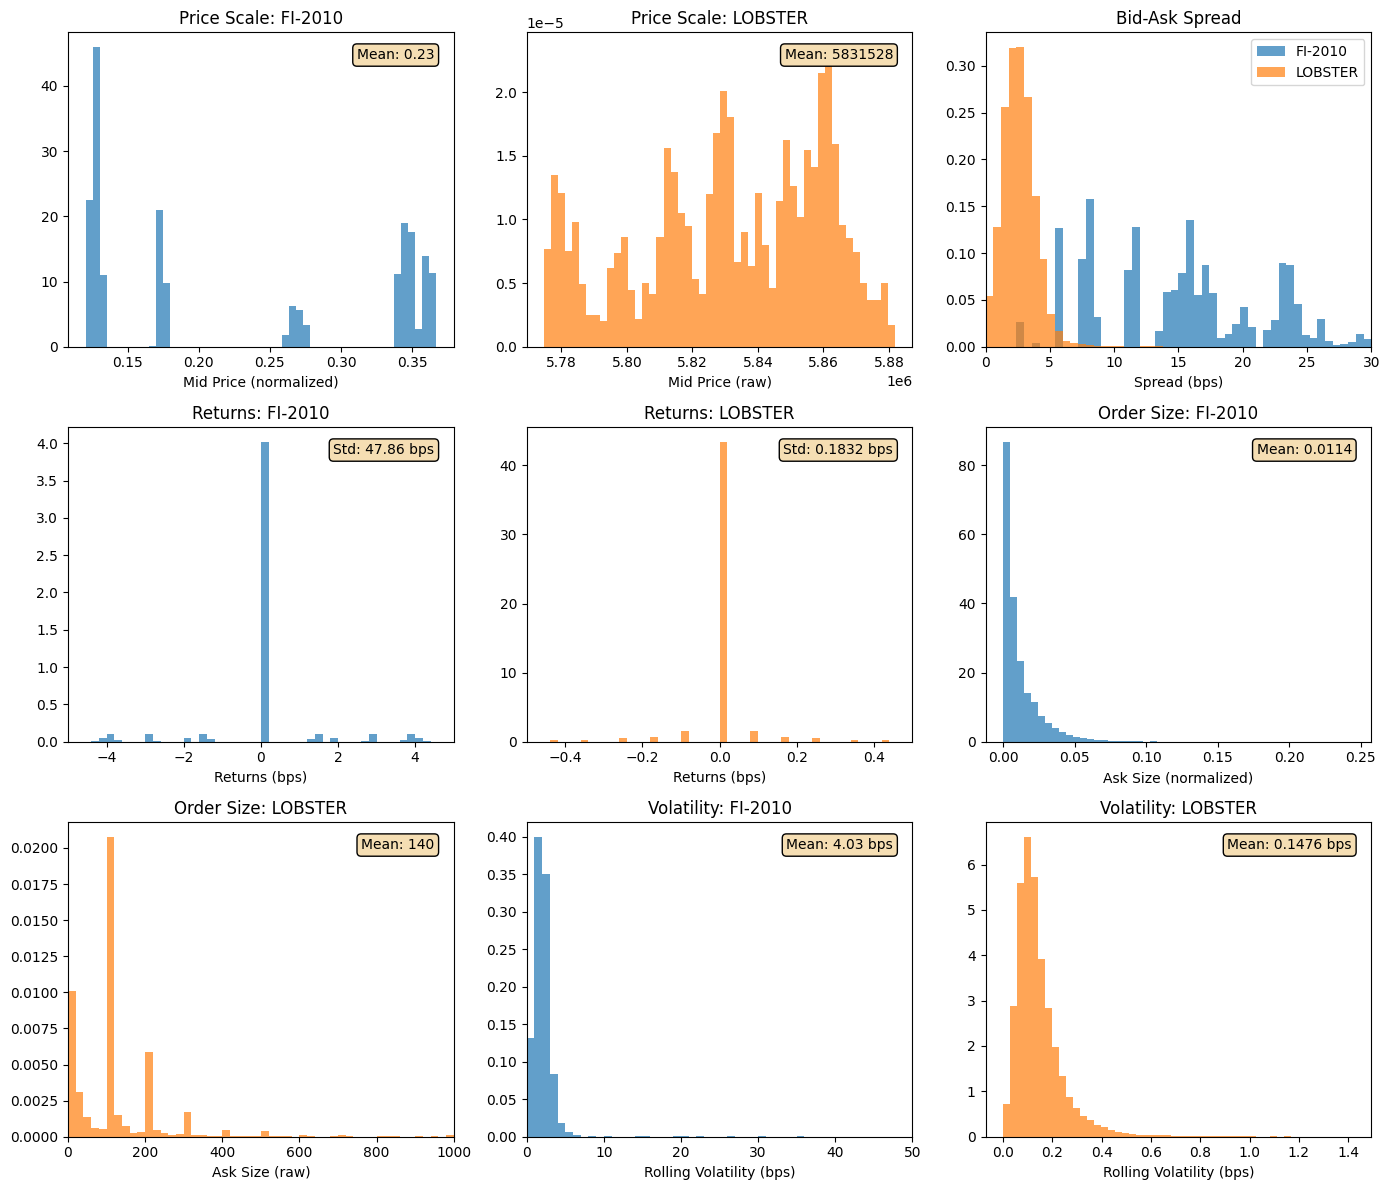

Saved: distribution_comparison.png

DISTRIBUTION STATISTICS: FI-2010 vs LOBSTER AAPL
Metric                            FI-2010         LOBSTER           Ratio
----------------------------------------------------------------------
Price Mean                           0.23         5831528       25402985x
Price Std                            0.10           28350         279337x
Spread Mean (bps)                   16.50            2.63            6.3x
Return Std (bps)                  47.8604          0.1832            261x
Order Size Mean                    0.0114             140          12279x
Volatility Mean (bps)                4.03          0.1476             27x

LATEX TABLE (copy to Overleaf)

\begin{table}[H]
\centering
\caption{Distribution Statistics: FI-2010 vs LOBSTER AAPL}
\begin{tabular}{lccc}
\toprule
Metric & FI-2010 & LOBSTER AAPL & Ratio \\
\midrule
Price Mean & 0.23 & 5831528 & 25402985x \\
Price Std & 0.10 & 28350 & 279337x \\
Spread Mean (bps) & 16.50 & 2.63 & 6.3x \\

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Calculate data
fi_mid = (fi_lob[:, 0] + fi_lob[:, 2]) / 2
lob_mid = (lobster_raw_correct['AAPL'][:, 0] + lobster_raw_correct['AAPL'][:, 2]) / 2

fi_returns = np.diff(fi_mid) / fi_mid[:-1]
lob_returns = np.diff(lob_mid) / lob_mid[:-1]
fi_returns_bps = fi_returns * 10000
lob_returns_bps = lob_returns * 10000

fi_spread_bps = (fi_lob[:, 0] - fi_lob[:, 2]) / fi_mid * 10000
lob_spread_bps = (lobster_raw_correct['AAPL'][:, 0] - lobster_raw_correct['AAPL'][:, 2]) / lob_mid * 10000

fi_ask_vol = fi_lob[:, 1]
lob_ask_vol = lobster_raw_correct['AAPL'][:, 1]

window = 100
fi_rolling_vol = pd.Series(fi_returns_bps).rolling(window).std().dropna().values
lob_rolling_vol = pd.Series(lob_returns_bps).rolling(window).std().dropna().values

# =============================================================================
# FIGURE - 3x3 grid
# =============================================================================
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

# [0,0] Price Scale: FI-2010
axes[0, 0].hist(fi_mid, bins=50, alpha=0.7, color='#1f77b4', density=True)
axes[0, 0].set_xlabel('Mid Price (normalized)')
axes[0, 0].set_title('Price Scale: FI-2010')
axes[0, 0].annotate(f'Mean: {fi_mid.mean():.2f}', xy=(0.95, 0.95), xycoords='axes fraction', 
                    ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# [0,1] Price Scale: LOBSTER
axes[0, 1].hist(lob_mid, bins=50, alpha=0.7, color='#ff7f0e', density=True)
axes[0, 1].set_xlabel('Mid Price (raw)')
axes[0, 1].set_title('Price Scale: LOBSTER')
axes[0, 1].annotate(f'Mean: {lob_mid.mean():.0f}', xy=(0.95, 0.95), xycoords='axes fraction', 
                    ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# [0,2] Bid-Ask Spread (both, clipped)
axes[0, 2].hist(fi_spread_bps, bins=50, alpha=0.7, label='FI-2010', density=True, range=(0, 30))
axes[0, 2].hist(lob_spread_bps, bins=50, alpha=0.7, label='LOBSTER', density=True, range=(0, 30))
axes[0, 2].set_xlim(0, 30)
axes[0, 2].set_xlabel('Spread (bps)')
axes[0, 2].set_title('Bid-Ask Spread')
axes[0, 2].legend()

# [1,0] Returns: FI-2010
axes[1, 0].hist(fi_returns_bps, bins=50, alpha=0.7, color='#1f77b4', density=True, range=(-5, 5))
axes[1, 0].set_xlim(-5, 5)
axes[1, 0].set_xlabel('Returns (bps)')
axes[1, 0].set_title('Returns: FI-2010')
axes[1, 0].annotate(f'Std: {np.std(fi_returns_bps):.2f} bps', xy=(0.95, 0.95), xycoords='axes fraction', 
                    ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# [1,1] Returns: LOBSTER
axes[1, 1].hist(lob_returns_bps, bins=50, alpha=0.7, color='#ff7f0e', density=True, range=(-0.5, 0.5))
axes[1, 1].set_xlim(-0.5, 0.5)
axes[1, 1].set_xlabel('Returns (bps)')
axes[1, 1].set_title('Returns: LOBSTER')
axes[1, 1].annotate(f'Std: {np.std(lob_returns_bps):.4f} bps', xy=(0.95, 0.95), xycoords='axes fraction', 
                    ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# [1,2] Order Size: FI-2010
axes[1, 2].hist(fi_ask_vol, bins=50, alpha=0.7, color='#1f77b4', density=True)
axes[1, 2].set_xlabel('Ask Size (normalized)')
axes[1, 2].set_title('Order Size: FI-2010')
axes[1, 2].annotate(f'Mean: {fi_ask_vol.mean():.4f}', xy=(0.95, 0.95), xycoords='axes fraction', 
                    ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# [2,0] Order Size: LOBSTER (clipped)
axes[2, 0].hist(lob_ask_vol, bins=50, alpha=0.7, color='#ff7f0e', density=True, range=(0, 1000))
axes[2, 0].set_xlim(0, 1000)
axes[2, 0].set_xlabel('Ask Size (raw)')
axes[2, 0].set_title('Order Size: LOBSTER')
axes[2, 0].annotate(f'Mean: {lob_ask_vol.mean():.0f}', xy=(0.95, 0.95), xycoords='axes fraction', 
                    ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# [2,1] Volatility: FI-2010 (clipped)
axes[2, 1].hist(fi_rolling_vol, bins=50, alpha=0.7, color='#1f77b4', density=True, range=(0, 50))
axes[2, 1].set_xlim(0, 50)
axes[2, 1].set_xlabel('Rolling Volatility (bps)')
axes[2, 1].set_title('Volatility: FI-2010')
axes[2, 1].annotate(f'Mean: {fi_rolling_vol.mean():.2f} bps', xy=(0.95, 0.95), xycoords='axes fraction', 
                    ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

# [2,2] Volatility: LOBSTER
axes[2, 2].hist(lob_rolling_vol, bins=50, alpha=0.7, color='#ff7f0e', density=True)
axes[2, 2].set_xlabel('Rolling Volatility (bps)')
axes[2, 2].set_title('Volatility: LOBSTER')
axes[2, 2].annotate(f'Mean: {lob_rolling_vol.mean():.4f} bps', xy=(0.95, 0.95), xycoords='axes fraction', 
                    ha='right', va='top', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat'))

plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: distribution_comparison.png")

# =============================================================================
# STATISTICS OUTPUT
# =============================================================================
print("\n" + "="*70)
print("DISTRIBUTION STATISTICS: FI-2010 vs LOBSTER AAPL")
print("="*70)

print(f"{'Metric':<25} {'FI-2010':>15} {'LOBSTER':>15} {'Ratio':>15}")
print("-"*70)
print(f"{'Price Mean':<25} {fi_mid.mean():>15.2f} {lob_mid.mean():>15.0f} {lob_mid.mean()/fi_mid.mean():>14.0f}x")
print(f"{'Price Std':<25} {fi_mid.std():>15.2f} {lob_mid.std():>15.0f} {lob_mid.std()/fi_mid.std():>14.0f}x")
print(f"{'Spread Mean (bps)':<25} {fi_spread_bps.mean():>15.2f} {lob_spread_bps.mean():>15.2f} {fi_spread_bps.mean()/lob_spread_bps.mean():>14.1f}x")
print(f"{'Return Std (bps)':<25} {np.std(fi_returns_bps):>15.4f} {np.std(lob_returns_bps):>15.4f} {np.std(fi_returns_bps)/np.std(lob_returns_bps):>14.0f}x")
print(f"{'Order Size Mean':<25} {fi_ask_vol.mean():>15.4f} {lob_ask_vol.mean():>15.0f} {lob_ask_vol.mean()/fi_ask_vol.mean():>14.0f}x")
print(f"{'Volatility Mean (bps)':<25} {fi_rolling_vol.mean():>15.2f} {lob_rolling_vol.mean():>15.4f} {fi_rolling_vol.mean()/lob_rolling_vol.mean():>14.0f}x")
print("="*70)

# =============================================================================
# LATEX TABLE
# =============================================================================
latex_table = r"""
\begin{table}[H]
\centering
\caption{Distribution Statistics: FI-2010 vs LOBSTER AAPL}
\begin{tabular}{lccc}
\toprule
Metric & FI-2010 & LOBSTER AAPL & Ratio \\
\midrule
Price Mean & """ + f"{fi_mid.mean():.2f}" + r""" & """ + f"{lob_mid.mean():.0f}" + r""" & """ + f"{lob_mid.mean()/fi_mid.mean():.0f}" + r"""x \\
Price Std & """ + f"{fi_mid.std():.2f}" + r""" & """ + f"{lob_mid.std():.0f}" + r""" & """ + f"{lob_mid.std()/fi_mid.std():.0f}" + r"""x \\
Spread Mean (bps) & """ + f"{fi_spread_bps.mean():.2f}" + r""" & """ + f"{lob_spread_bps.mean():.2f}" + r""" & """ + f"{fi_spread_bps.mean()/lob_spread_bps.mean():.1f}" + r"""x \\
Return Std (bps) & """ + f"{np.std(fi_returns_bps):.4f}" + r""" & """ + f"{np.std(lob_returns_bps):.4f}" + r""" & """ + f"{np.std(fi_returns_bps)/np.std(lob_returns_bps):.0f}" + r"""x \\
Order Size Mean & """ + f"{fi_ask_vol.mean():.4f}" + r""" & """ + f"{lob_ask_vol.mean():.0f}" + r""" & """ + f"{lob_ask_vol.mean()/fi_ask_vol.mean():.0f}" + r"""x \\
Volatility Mean (bps) & """ + f"{fi_rolling_vol.mean():.2f}" + r""" & """ + f"{lob_rolling_vol.mean():.4f}" + r""" & """ + f"{fi_rolling_vol.mean()/lob_rolling_vol.mean():.0f}" + r"""x \\
\bottomrule
\end{tabular}
\label{tab:distribution_stats}
\end{table}
"""

print("\n" + "="*70)
print("LATEX TABLE (copy to Overleaf)")
print("="*70)
print(latex_table)

c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\numpy\lib\_histograms_impl.py:901: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


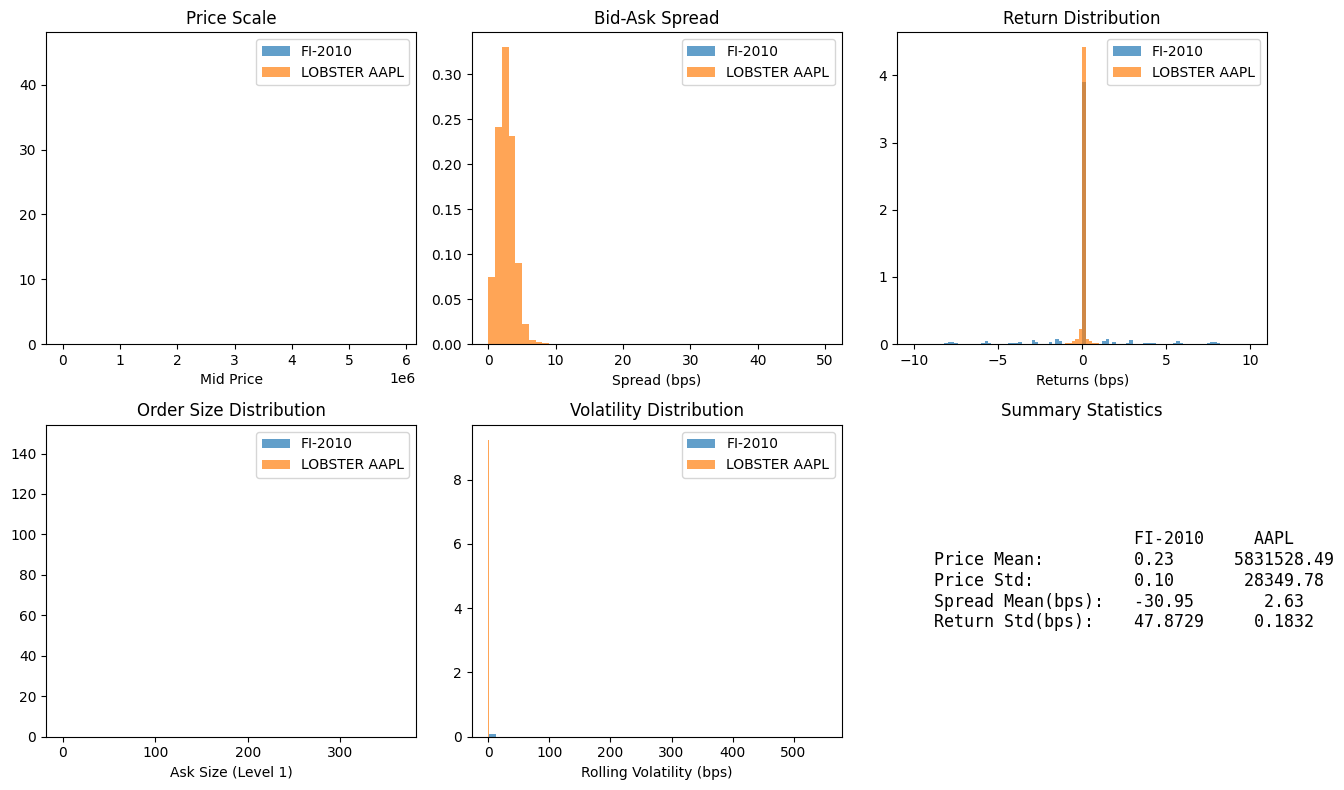

Saved: distribution_comparison.png


In [18]:
import matplotlib.pyplot as plt

# Calculate key metrics for both datasets
def calc_metrics(data):
    """Calculate LOB metrics. Format: ask prices (cols 0,2,4..18), ask sizes (1,3,5..19), 
    bid prices (20,22,24..38), bid sizes (21,23,25..39)"""
    ask1_price = data[:, 0]
    bid1_price = data[:, 20]
    ask1_size = data[:, 1]
    bid1_size = data[:, 21]
    
    mid_price = (ask1_price + bid1_price) / 2
    spread = ask1_price - bid1_price
    spread_bps = (spread / mid_price) * 10000  # basis points
    
    # Returns (mid-price changes)
    returns = np.diff(mid_price) / mid_price[:-1]
    
    return {
        'mid_price': mid_price,
        'spread_bps': spread_bps,
        'returns': returns,
        'ask1_size': ask1_size,
        'bid1_size': bid1_size
    }

fi_metrics = calc_metrics(fi_lob)
aapl_metrics = calc_metrics(lobster_raw['AAPL'])

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# 1. Mid-price scale
axes[0,0].hist(fi_metrics['mid_price'], bins=50, alpha=0.7, label='FI-2010', density=True)
axes[0,0].hist(aapl_metrics['mid_price'], bins=50, alpha=0.7, label='LOBSTER AAPL', density=True)
axes[0,0].set_xlabel('Mid Price')
axes[0,0].set_title('Price Scale')
axes[0,0].legend()

# 2. Spread (basis points)
axes[0,1].hist(fi_metrics['spread_bps'], bins=50, alpha=0.7, label='FI-2010', density=True, range=(0, 50))
axes[0,1].hist(aapl_metrics['spread_bps'], bins=50, alpha=0.7, label='LOBSTER AAPL', density=True, range=(0, 50))
axes[0,1].set_xlabel('Spread (bps)')
axes[0,1].set_title('Bid-Ask Spread')
axes[0,1].legend()

# 3. Returns distribution
axes[0,2].hist(fi_metrics['returns']*10000, bins=100, alpha=0.7, label='FI-2010', density=True, range=(-10, 10))
axes[0,2].hist(aapl_metrics['returns']*10000, bins=100, alpha=0.7, label='LOBSTER AAPL', density=True, range=(-10, 10))
axes[0,2].set_xlabel('Returns (bps)')
axes[0,2].set_title('Return Distribution')
axes[0,2].legend()

# 4. Ask size
axes[1,0].hist(fi_metrics['ask1_size'], bins=50, alpha=0.7, label='FI-2010', density=True, range=(0, np.percentile(fi_metrics['ask1_size'], 95)))
axes[1,0].hist(aapl_metrics['ask1_size'], bins=50, alpha=0.7, label='LOBSTER AAPL', density=True, range=(0, np.percentile(aapl_metrics['ask1_size'], 95)))
axes[1,0].set_xlabel('Ask Size (Level 1)')
axes[1,0].set_title('Order Size Distribution')
axes[1,0].legend()

# 5. Volatility (rolling std of returns)
window = 1000
fi_vol = pd.Series(fi_metrics['returns']).rolling(window).std() * 10000
aapl_vol = pd.Series(aapl_metrics['returns']).rolling(window).std() * 10000
axes[1,1].hist(fi_vol.dropna(), bins=50, alpha=0.7, label='FI-2010', density=True)
axes[1,1].hist(aapl_vol.dropna(), bins=50, alpha=0.7, label='LOBSTER AAPL', density=True)
axes[1,1].set_xlabel('Rolling Volatility (bps)')
axes[1,1].set_title('Volatility Distribution')
axes[1,1].legend()

# 6. Summary stats table
axes[1,2].axis('off')
stats_text = f"""
                    FI-2010     AAPL
Price Mean:         {fi_metrics['mid_price'].mean():.2f}      {aapl_metrics['mid_price'].mean():.2f}
Price Std:          {fi_metrics['mid_price'].std():.2f}       {aapl_metrics['mid_price'].std():.2f}
Spread Mean(bps):   {fi_metrics['spread_bps'].mean():.2f}       {aapl_metrics['spread_bps'].mean():.2f}
Return Std(bps):    {fi_metrics['returns'].std()*10000:.4f}     {aapl_metrics['returns'].std()*10000:.4f}
"""
axes[1,2].text(0.1, 0.5, stats_text, fontsize=12, family='monospace', verticalalignment='center')
axes[1,2].set_title('Summary Statistics')

plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=150)
plt.show()

print("Saved: distribution_comparison.png")

In [19]:
# Correct FI-2010 format
def calc_metrics_fi2010(data):
    """FI-2010: cols 0-9 ask prices, 10-19 ask sizes, 20-29 bid prices, 30-39 bid sizes"""
    ask1_price = data[:, 0]
    bid1_price = data[:, 20]
    ask1_size = data[:, 10]
    bid1_size = data[:, 30]
    
    mid_price = (ask1_price + bid1_price) / 2
    spread = ask1_price - bid1_price
    spread_bps = (spread / mid_price) * 10000
    returns = np.diff(mid_price) / mid_price[:-1]
    
    return {
        'mid_price': mid_price,
        'spread_bps': spread_bps,
        'returns': returns,
        'ask1_size': ask1_size,
        'bid1_size': bid1_size
    }

def calc_metrics_lobster(data):
    """LOBSTER reordered: cols 0-19 asks (p,s alternating), 20-39 bids"""
    ask1_price = data[:, 0]
    bid1_price = data[:, 20]
    ask1_size = data[:, 1]
    bid1_size = data[:, 21]
    
    mid_price = (ask1_price + bid1_price) / 2
    spread = ask1_price - bid1_price
    spread_bps = (spread / mid_price) * 10000
    returns = np.diff(mid_price) / mid_price[:-1]
    
    return {
        'mid_price': mid_price,
        'spread_bps': spread_bps,
        'returns': returns,
        'ask1_size': ask1_size,
        'bid1_size': bid1_size
    }

fi_metrics = calc_metrics_fi2010(fi_lob)
aapl_metrics = calc_metrics_lobster(lobster_raw['AAPL'])

print("=== FI-2010 ===")
print(f"Price Mean: {fi_metrics['mid_price'].mean():.4f}")
print(f"Price Std: {fi_metrics['mid_price'].std():.4f}")
print(f"Spread Mean (bps): {fi_metrics['spread_bps'].mean():.2f}")
print(f"Return Std (bps): {fi_metrics['returns'].std()*10000:.4f}")

print("\n=== LOBSTER AAPL ===")
print(f"Price Mean: {aapl_metrics['mid_price'].mean():.2f}")
print(f"Price Std: {aapl_metrics['mid_price'].std():.2f}")
print(f"Spread Mean (bps): {aapl_metrics['spread_bps'].mean():.2f}")
print(f"Return Std (bps): {aapl_metrics['returns'].std()*10000:.4f}")

=== FI-2010 ===
Price Mean: 0.2301
Price Std: 0.1016
Spread Mean (bps): -30.95
Return Std (bps): 47.8729

=== LOBSTER AAPL ===
Price Mean: 5831528.49
Price Std: 28349.78
Spread Mean (bps): 2.63
Return Std (bps): 0.1832


In [20]:
# Check first row of FI-2010 to understand format
print("FI-2010 first row (first 10 values):", fi_lob[0, :10])
print("FI-2010 first row (values 20-30):", fi_lob[0, 20:30])

# Check if asks > bids (should be true)
print(f"\nCol 0 mean: {fi_lob[:, 0].mean():.4f}")
print(f"Col 20 mean: {fi_lob[:, 20].mean():.4f}")

# Try different interpretation: maybe it's ask1, bid1, ask2, bid2...
print(f"\nAlt check - Col 0 vs Col 1:")
print(f"Col 0 mean: {fi_lob[:, 0].mean():.4f}")
print(f"Col 1 mean: {fi_lob[:, 1].mean():.4f}")

FI-2010 first row (first 10 values): [0.2615  0.00353 0.2606  0.00326 0.2618  0.002   0.2604  0.00682 0.2619
 0.00164]
FI-2010 first row (values 20-30): [0.2623  0.00837 0.2595  0.001   0.2625  0.0015  0.2593  0.00143 0.2626
 0.00787]

Col 0 mean: 0.2298
Col 20 mean: 0.2304

Alt check - Col 0 vs Col 1:
Col 0 mean: 0.2298
Col 1 mean: 0.0114


In [16]:
def load_lobster_fi2010_format(filepath):
    """Load LOBSTER and keep same format as FI-2010 (interleaved by level)"""
    df = pd.read_csv(filepath, header=None)
    # LOBSTER raw: ask1_p, ask1_s, bid1_p, bid1_s, ask2_p, ask2_s, bid2_p, bid2_s, ...
    # FI-2010:     ask1_p, ask1_s, bid1_p, bid1_s, ask2_p, ask2_s, bid2_p, bid2_s, ...
    # They're the same! No reordering needed.
    return df.values

# Reload LOBSTER without reordering
lobster_raw_correct = {}
for stock in stocks:
    filepath = f"{lobster_path}{stock}_2012-06-21_34200000_57600000_orderbook_10.csv"
    lobster_raw_correct[stock] = load_lobster_fi2010_format(filepath)

# Verify format matches
print("LOBSTER AAPL first row (first 8 values):")
print(lobster_raw_correct['AAPL'][0, :8])
print("\nExpected: ask1_p, ask1_s, bid1_p, bid1_s, ask2_p, ask2_s, bid2_p, bid2_s")

# Check spread is positive
ask1 = lobster_raw_correct['AAPL'][:, 0]
bid1 = lobster_raw_correct['AAPL'][:, 2]
spread = ask1 - bid1
print(f"\nSpread check: mean={spread.mean():.2f}, all positive={np.all(spread > 0)}")

LOBSTER AAPL first row (first 8 values):
[5859400     200 5853300      18 5859800     200 5853000     150]

Expected: ask1_p, ask1_s, bid1_p, bid1_s, ask2_p, ask2_s, bid2_p, bid2_s

Spread check: mean=1534.89, all positive=True


In [22]:
def normalize_data(data):
    """Z-score normalization"""
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1
    return (data - mean) / std

def create_labels_correct(data, k=10):
    """Labels using correct column order: col 0=ask1, col 2=bid1"""
    mid_price = (data[:, 0] + data[:, 2]) / 2
    labels = np.zeros(len(mid_price))
    
    for i in range(len(mid_price) - k):
        future_avg = np.mean(mid_price[i+1:i+k+1])
        current = mid_price[i]
        pct_change = (future_avg - current) / current
        
        if pct_change > 0.0002:
            labels[i] = 2  # up
        elif pct_change < -0.0002:
            labels[i] = 0  # down
        else:
            labels[i] = 1  # stationary
    
    return labels.astype(int)

# Process AAPL with correct format
stock = 'AAPL'
data_norm = normalize_data(lobster_raw_correct[stock].astype(np.float32))
labels = create_labels_correct(lobster_raw_correct[stock], k=10)
X_test, y_test = prepare_sequences_subset(data_norm, labels, T=100, max_samples=50000)

print(f"{stock}: {X_test.shape[0]} samples")
print(f"Label distribution: {np.bincount(y_test)}")

# Evaluate
dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_test).unsqueeze(1),
    torch.LongTensor(y_test)
)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(f"\nCorrected LOBSTER ({stock}):")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=['Down', 'Stationary', 'Up']))

AAPL: 50000 samples
Label distribution: [  154 49740   106]

Corrected LOBSTER (AAPL):
Accuracy: 0.0036
              precision    recall  f1-score   support

        Down       0.00      0.49      0.01       154
  Stationary       1.00      0.00      0.00     49740
          Up       0.00      0.51      0.00       106

    accuracy                           0.00     50000
   macro avg       0.34      0.33      0.00     50000
weighted avg       0.99      0.00      0.00     50000



In [23]:
# Find threshold that gives similar label distribution to FI-2010
def get_label_distribution(data, threshold):
    mid_price = (data[:, 0] + data[:, 2]) / 2
    labels = np.zeros(len(mid_price) - 10)
    
    for i in range(len(labels)):
        future_avg = np.mean(mid_price[i+1:i+11])
        current = mid_price[i]
        pct_change = (future_avg - current) / current
        
        if pct_change > threshold:
            labels[i] = 2
        elif pct_change < -threshold:
            labels[i] = 0
        else:
            labels[i] = 1
    
    counts = np.bincount(labels.astype(int), minlength=3)
    return counts / len(labels) * 100

# Test different thresholds for LOBSTER
print("LOBSTER AAPL label distribution by threshold:")
print("Threshold\tDown%\tStat%\tUp%")
for thresh in [0.0002, 0.0001, 0.00005, 0.00002, 0.00001, 0.000005]:
    dist = get_label_distribution(lobster_raw_correct['AAPL'], thresh)
    print(f"{thresh:.6f}\t{dist[0]:.1f}\t{dist[1]:.1f}\t{dist[2]:.1f}")

# FI-2010 reference
print("\nFI-2010 label distribution (threshold=0.0002):")
dist_fi = get_label_distribution(fi_lob, 0.0002)
print(f"0.000200\t{dist_fi[0]:.1f}\t{dist_fi[1]:.1f}\t{dist_fi[2]:.1f}")

LOBSTER AAPL label distribution by threshold:
Threshold	Down%	Stat%	Up%
0.000200	0.0	99.9	0.0
0.000100	0.7	98.7	0.6
0.000050	3.8	92.6	3.7
0.000020	12.8	74.6	12.6
0.000010	21.1	58.1	20.8
0.000005	28.7	43.2	28.1

FI-2010 label distribution (threshold=0.0002):
0.000200	22.3	55.0	22.8


In [24]:
def create_labels_calibrated(data, k=10, threshold=0.00001):
    """Labels with calibrated threshold for LOBSTER"""
    mid_price = (data[:, 0] + data[:, 2]) / 2
    labels = np.zeros(len(mid_price))
    
    for i in range(len(mid_price) - k):
        future_avg = np.mean(mid_price[i+1:i+k+1])
        current = mid_price[i]
        pct_change = (future_avg - current) / current
        
        if pct_change > threshold:
            labels[i] = 2
        elif pct_change < -threshold:
            labels[i] = 0
        else:
            labels[i] = 1
    
    return labels.astype(int)

# Re-evaluate with calibrated labels
stock = 'AAPL'
data_norm = normalize_data(lobster_raw_correct[stock].astype(np.float32))
labels = create_labels_calibrated(lobster_raw_correct[stock], k=10, threshold=0.00001)
X_test, y_test = prepare_sequences_subset(data_norm, labels, T=100, max_samples=50000)

print(f"{stock}: {X_test.shape[0]} samples")
print(f"Label distribution: {np.bincount(y_test)}")

# Evaluate
dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_test).unsqueeze(1),
    torch.LongTensor(y_test)
)
test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print(f"\nCalibrated LOBSTER ({stock}):")
print(f"Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(classification_report(all_labels, all_preds, target_names=['Down', 'Stationary', 'Up']))

AAPL: 50000 samples
Label distribution: [13669 21838 14493]

Calibrated LOBSTER (AAPL):
Accuracy: 0.2862
              precision    recall  f1-score   support

        Down       0.28      0.41      0.33     13669
  Stationary       0.62      0.00      0.00     21838
          Up       0.29      0.59      0.39     14493

    accuracy                           0.29     50000
   macro avg       0.40      0.34      0.24     50000
weighted avg       0.43      0.29      0.21     50000



In [25]:
results_calibrated = {}

for stock in stocks:
    data_norm = normalize_data(lobster_raw_correct[stock].astype(np.float32))
    labels = create_labels_calibrated(lobster_raw_correct[stock], k=10, threshold=0.00001)
    X_test, y_test = prepare_sequences_subset(data_norm, labels, T=100, max_samples=50000)
    
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_test).unsqueeze(1),
        torch.LongTensor(y_test)
    )
    test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = classification_report(all_labels, all_preds, output_dict=True)['macro avg']['f1-score']
    results_calibrated[stock] = {'acc': acc, 'f1': f1}
    print(f"{stock}: Acc={acc:.2%}, F1={f1:.2%}, Labels={np.bincount(y_test)}")

print("\n=== Summary (Calibrated Threshold) ===")
print("Stock\t\tAccuracy\tF1")
print("-" * 35)
for stock, res in results_calibrated.items():
    print(f"{stock}\t\t{res['acc']:.2%}\t\t{res['f1']:.2%}")
avg_acc = np.mean([r['acc'] for r in results_calibrated.values()])
avg_f1 = np.mean([r['f1'] for r in results_calibrated.values()])
print("-" * 35)
print(f"Average\t\t{avg_acc:.2%}\t\t{avg_f1:.2%}")

AAPL: Acc=28.62%, F1=24.21%, Labels=[13669 21838 14493]
AMZN: Acc=23.83%, F1=21.15%, Labels=[12942 24815 12243]
GOOG: Acc=25.13%, F1=21.77%, Labels=[14364 23484 12152]
INTC: Acc=31.15%, F1=23.04%, Labels=[ 3681 42719  3600]
MSFT: Acc=30.67%, F1=22.07%, Labels=[ 3818 42492  3690]

=== Summary (Calibrated Threshold) ===
Stock		Accuracy	F1
-----------------------------------
AAPL		28.62%		24.21%
AMZN		23.83%		21.15%
GOOG		25.13%		21.77%
INTC		31.15%		23.04%
MSFT		30.67%		22.07%
-----------------------------------
Average		27.88%		22.45%


In [26]:
def normalize_zscore(data):
    """Z-score: (x - mean) / std"""
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    std[std == 0] = 1
    return (data - mean) / std

def normalize_minmax(data):
    """Min-max: scale to [0, 1]"""
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    range_val = max_val - min_val
    range_val[range_val == 0] = 1
    return (data - min_val) / range_val

def normalize_decimal_precision(data):
    """Decimal precision: divide by power of 10 to get small numbers"""
    # Find max value and scale down
    max_val = np.max(np.abs(data), axis=0)
    scale = 10 ** np.floor(np.log10(max_val + 1))
    return data / scale

def normalize_match_fi2010(data, fi_data):
    """Force LOBSTER to have same mean/std as FI-2010 per column"""
    fi_mean = np.mean(fi_data, axis=0)
    fi_std = np.std(fi_data, axis=0)
    
    data_mean = np.mean(data, axis=0)
    data_std = np.std(data, axis=0)
    data_std[data_std == 0] = 1
    
    # Standardize then rescale to FI-2010 statistics
    normalized = (data - data_mean) / data_std
    return normalized * fi_std + fi_mean

# Test each normalization on AAPL
stock = 'AAPL'
raw_data = lobster_raw_correct[stock].astype(np.float32)
labels = create_labels_calibrated(lobster_raw_correct[stock], k=10, threshold=0.00001)

normalizations = {
    'Z-score': normalize_zscore(raw_data),
    'Min-max': normalize_minmax(raw_data),
    'Decimal': normalize_decimal_precision(raw_data),
    'Match FI-2010': normalize_match_fi2010(raw_data, fi_lob)
}

print("Testing normalizations on AAPL...\n")
norm_results = {}

for name, data_norm in normalizations.items():
    X_test, y_test = prepare_sequences_subset(data_norm, labels, T=100, max_samples=50000)
    
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_test).unsqueeze(1),
        torch.LongTensor(y_test)
    )
    test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = classification_report(all_labels, all_preds, output_dict=True)['macro avg']['f1-score']
    norm_results[name] = {'acc': acc, 'f1': f1}
    print(f"{name}: Acc={acc:.2%}, F1={f1:.2%}")

print("\n=== Normalization Comparison ===")
print(f"{'Method':<15} {'Accuracy':>10} {'F1':>10}")
print("-" * 37)
for name, res in norm_results.items():
    print(f"{name:<15} {res['acc']:>10.2%} {res['f1']:>10.2%}")
print("-" * 37)
print(f"{'FI-2010 baseline':<15} {'74.36%':>10} {'74.37%':>10}")

Testing normalizations on AAPL...

Z-score: Acc=28.62%, F1=24.21%


c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Min-max: Acc=28.93%, F1=15.11%


c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Decimal: Acc=43.29%, F1=22.64%
Match FI-2010: Acc=38.70%, F1=31.62%

=== Normalization Comparison ===
Method            Accuracy         F1
-------------------------------------
Z-score             28.62%     24.21%
Min-max             28.93%     15.11%
Decimal             43.29%     22.64%
Match FI-2010       38.70%     31.62%
-------------------------------------
FI-2010 baseline     74.36%     74.37%


In [27]:
# Create hooks to capture intermediate outputs
class ActivationExtractor:
    def __init__(self, model):
        self.model = model
        self.activations = {}
        
        # Register hooks on key layers
        model.conv1.register_forward_hook(self._get_hook('conv1'))
        model.conv2.register_forward_hook(self._get_hook('conv2'))
        model.conv3.register_forward_hook(self._get_hook('conv3'))
        model.lstm.register_forward_hook(self._get_hook('lstm'))
    
    def _get_hook(self, name):
        def hook(module, input, output):
            if isinstance(output, tuple):  # LSTM returns (output, (h_n, c_n))
                self.activations[name] = output[0].detach()
            else:
                self.activations[name] = output.detach()
        return hook
    
    def get_activations(self, x):
        self.activations = {}
        with torch.no_grad():
            _ = self.model(x)
        return self.activations

extractor = ActivationExtractor(model)

# Prepare small samples from both datasets
# FI-2010: load and prepare
fi_normalized = normalize_zscore(fi_lob.astype(np.float32))
fi_labels = create_labels_calibrated(fi_lob, k=10, threshold=0.0002)  # original threshold
X_fi, y_fi = prepare_sequences_subset(fi_normalized, fi_labels, T=100, max_samples=5000)

# LOBSTER: use decimal normalization (best performer)
lob_normalized = normalize_decimal_precision(lobster_raw_correct['AAPL'].astype(np.float32))
lob_labels = create_labels_calibrated(lobster_raw_correct['AAPL'], k=10, threshold=0.00001)
X_lob, y_lob = prepare_sequences_subset(lob_normalized, lob_labels, T=100, max_samples=5000)

print(f"FI-2010 samples: {X_fi.shape[0]}")
print(f"LOBSTER samples: {X_lob.shape[0]}")

FI-2010 samples: 5000
LOBSTER samples: 5000


In [28]:
# Get activations for both datasets
batch_fi = torch.FloatTensor(X_fi[:500]).unsqueeze(1).to(device)
batch_lob = torch.FloatTensor(X_lob[:500]).unsqueeze(1).to(device)

act_fi = extractor.get_activations(batch_fi)
act_lob = extractor.get_activations(batch_lob)

# Compare activation statistics
print("=== Activation Statistics ===\n")
print(f"{'Layer':<10} {'Dataset':<10} {'Mean':>12} {'Std':>12} {'Min':>12} {'Max':>12}")
print("-" * 70)

for layer in ['conv1', 'conv2', 'conv3', 'lstm']:
    fi_act = act_fi[layer].cpu().numpy().flatten()
    lob_act = act_lob[layer].cpu().numpy().flatten()
    
    print(f"{layer:<10} {'FI-2010':<10} {fi_act.mean():>12.4f} {fi_act.std():>12.4f} {fi_act.min():>12.4f} {fi_act.max():>12.4f}")
    print(f"{'':<10} {'LOBSTER':<10} {lob_act.mean():>12.4f} {lob_act.std():>12.4f} {lob_act.min():>12.4f} {lob_act.max():>12.4f}")
    print()

=== Activation Statistics ===

Layer      Dataset            Mean          Std          Min          Max
----------------------------------------------------------------------
conv1      FI-2010         27.1389      44.6072      -4.3811     329.0376
           LOBSTER        358.5076     459.8903     -27.5412    1760.9479

conv2      FI-2010         -0.0978       1.2241      -2.7009       2.9808
           LOBSTER         -0.0038       1.1561      -2.5113       2.5933

conv3      FI-2010         -0.0099       0.9394      -0.9091       6.2110
           LOBSTER          0.1163       0.7429      -0.8539       2.5415

lstm       FI-2010         -0.0043       0.5486      -0.9992       0.9990
           LOBSTER          0.0046       0.4476      -0.9963       0.9934



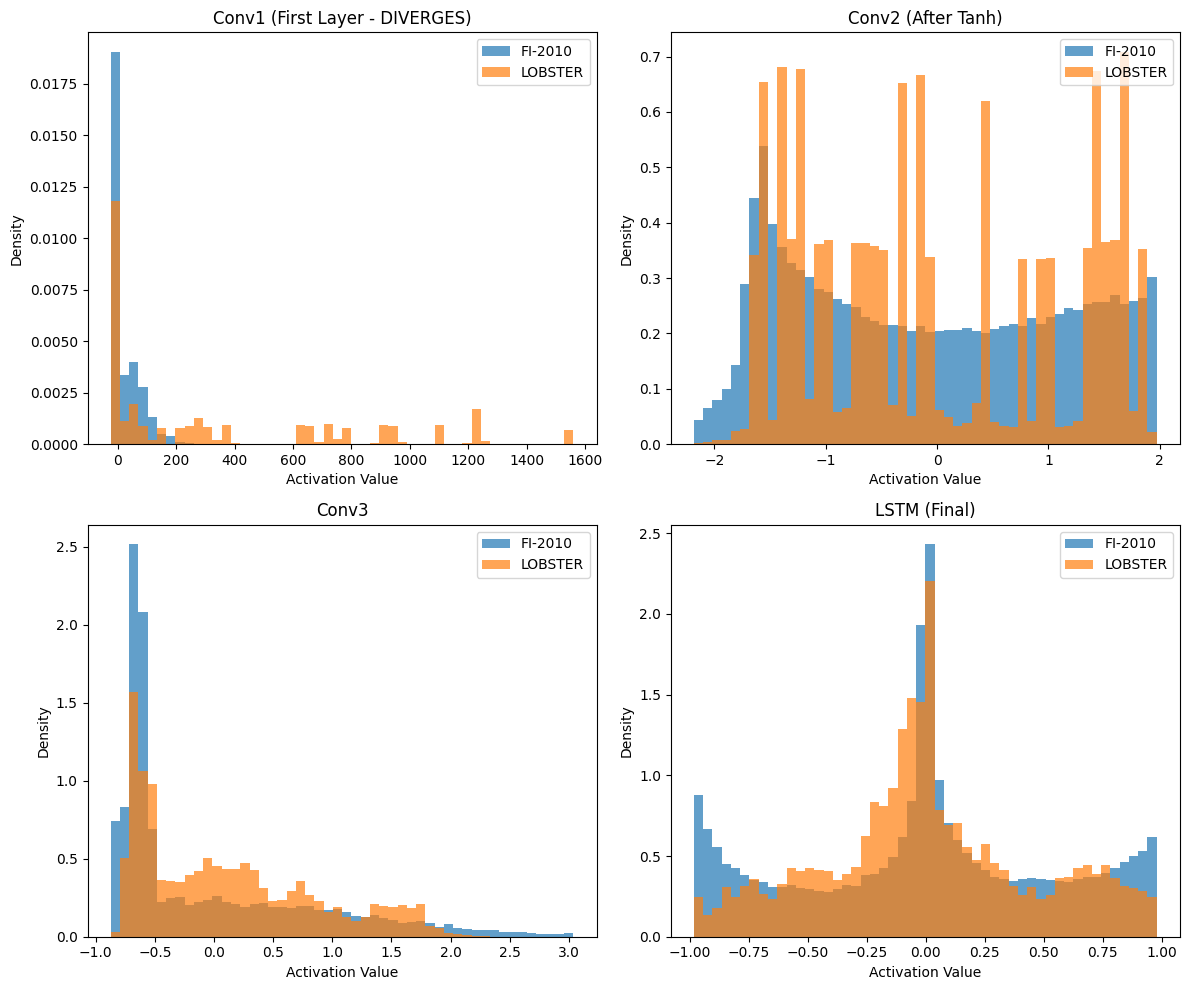

Saved: layer_activations.png


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

layers = ['conv1', 'conv2', 'conv3', 'lstm']
titles = ['Conv1 (First Layer - DIVERGES)', 'Conv2 (After Tanh)', 'Conv3', 'LSTM (Final)']

for idx, (layer, title) in enumerate(zip(layers, titles)):
    ax = axes[idx // 2, idx % 2]
    
    fi_act = act_fi[layer].cpu().numpy().flatten()
    lob_act = act_lob[layer].cpu().numpy().flatten()
    
    # Use percentiles to handle outliers
    low = min(np.percentile(fi_act, 1), np.percentile(lob_act, 1))
    high = max(np.percentile(fi_act, 99), np.percentile(lob_act, 99))
    
    ax.hist(fi_act, bins=50, alpha=0.7, label='FI-2010', density=True, range=(low, high))
    ax.hist(lob_act, bins=50, alpha=0.7, label='LOBSTER', density=True, range=(low, high))
    ax.set_xlabel('Activation Value')
    ax.set_ylabel('Density')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.savefig('layer_activations.png', dpi=150)
plt.show()

print("Saved: layer_activations.png")

In [30]:
# FI-2010 format: [ask1_p, ask1_v, bid1_p, bid1_v, ask2_p, ask2_v, bid2_p, bid2_v, ...]
# 40 columns = 10 levels × 4 features (ask_price, ask_vol, bid_price, bid_vol)

def get_feature_stats(data, name):
    """Calculate stats for feature groups"""
    stats = {}
    
    # Separate by feature type
    ask_prices = data[:, 0::4]   # cols 0, 4, 8, ... (10 columns)
    ask_volumes = data[:, 1::4]  # cols 1, 5, 9, ...
    bid_prices = data[:, 2::4]   # cols 2, 6, 10, ...
    bid_volumes = data[:, 3::4]  # cols 3, 7, 11, ...
    
    stats['ask_price_mean'] = ask_prices.mean()
    stats['ask_price_std'] = ask_prices.std()
    stats['ask_vol_mean'] = ask_volumes.mean()
    stats['ask_vol_std'] = ask_volumes.std()
    stats['bid_price_mean'] = bid_prices.mean()
    stats['bid_price_std'] = bid_prices.std()
    stats['bid_vol_mean'] = bid_volumes.mean()
    stats['bid_vol_std'] = bid_volumes.std()
    
    # Level 1 vs deeper levels
    level1 = data[:, :4]
    deeper = data[:, 4:]
    stats['level1_std'] = level1.std()
    stats['deeper_std'] = deeper.std()
    
    return stats

fi_stats = get_feature_stats(fi_lob, 'FI-2010')
lob_stats = get_feature_stats(lobster_raw_correct['AAPL'], 'LOBSTER')

print("=== Feature Group Comparison ===\n")
print(f"{'Feature':<20} {'FI-2010':>15} {'LOBSTER':>15} {'Ratio':>10}")
print("-" * 60)

for key in fi_stats:
    fi_val = fi_stats[key]
    lob_val = lob_stats[key]
    ratio = lob_val / fi_val if fi_val != 0 else float('inf')
    print(f"{key:<20} {fi_val:>15.4f} {lob_val:>15.4f} {ratio:>10.1f}x")

=== Feature Group Comparison ===

Feature                      FI-2010         LOBSTER      Ratio
------------------------------------------------------------
ask_price_mean                0.2304    5833438.6558 25323824.8x
ask_price_std                 0.1017      28699.1435   282210.9x
ask_vol_mean                  0.0194        149.6556     7695.1x
ask_vol_std                   0.0292        285.2832     9769.6x
bid_price_mean                0.2288    5829475.9072 25482127.3x
bid_price_std                 0.1013      27953.3563   276009.0x
bid_vol_mean                  0.0197        182.8901     9283.0x
bid_vol_std                   0.0282        449.2319    15927.8x
level1_std                    0.1309    2915752.1819 22276282.4x
deeper_std                    0.1285    2915710.4946 22683082.2x


In [31]:
# Normalize both datasets first, then compare distributions
fi_norm = normalize_zscore(fi_lob.astype(np.float32))
lob_norm = normalize_zscore(lobster_raw_correct['AAPL'].astype(np.float32))

def get_normalized_feature_stats(data):
    """Stats after normalization - compare variability patterns"""
    stats = {}
    
    ask_prices = data[:, 0::4]   # cols 0, 4, 8, ...
    ask_volumes = data[:, 1::4]  # cols 1, 5, 9, ...
    bid_prices = data[:, 2::4]   # cols 2, 6, 10, ...
    bid_volumes = data[:, 3::4]  # cols 3, 7, 11, ...
    
    # Variance (how much each feature type varies)
    stats['ask_price_var'] = ask_prices.var()
    stats['ask_vol_var'] = ask_volumes.var()
    stats['bid_price_var'] = bid_prices.var()
    stats['bid_vol_var'] = bid_volumes.var()
    
    # Autocorrelation (temporal patterns) - sample for speed
    sample = data[::100, :]
    stats['price_autocorr'] = np.corrcoef(sample[:-1, 0], sample[1:, 0])[0, 1]
    stats['vol_autocorr'] = np.corrcoef(sample[:-1, 1], sample[1:, 1])[0, 1]
    
    return stats

fi_nstats = get_normalized_feature_stats(fi_norm)
lob_nstats = get_normalized_feature_stats(lob_norm)

print("=== Normalized Feature Comparison ===\n")
print(f"{'Feature':<20} {'FI-2010':>12} {'LOBSTER':>12} {'Diff':>12}")
print("-" * 58)

for key in fi_nstats:
    fi_val = fi_nstats[key]
    lob_val = lob_nstats[key]
    diff = lob_val - fi_val
    print(f"{key:<20} {fi_val:>12.4f} {lob_val:>12.4f} {diff:>+12.4f}")

=== Normalized Feature Comparison ===

Feature                   FI-2010      LOBSTER         Diff
----------------------------------------------------------
ask_price_var              1.0000       1.0000      +0.0000
ask_vol_var                1.0000       1.0000      -0.0000
bid_price_var              1.0000       1.0000      -0.0000
bid_vol_var                1.0000       1.0000      +0.0000
price_autocorr             0.9976       0.9995      +0.0020
vol_autocorr               0.2613       0.0423      -0.2190


In [32]:
def prepare_price_only(data):
    """Keep only price columns, zero out volumes"""
    data_mod = data.copy()
    data_mod[:, 1::4] = 0  # ask volumes
    data_mod[:, 3::4] = 0  # bid volumes
    return data_mod

def prepare_volume_only(data):
    """Keep only volume columns, zero out prices"""
    data_mod = data.copy()
    data_mod[:, 0::4] = 0  # ask prices
    data_mod[:, 2::4] = 0  # bid prices
    return data_mod

# Test on LOBSTER AAPL with calibrated labels
stock = 'AAPL'
raw_data = lobster_raw_correct[stock].astype(np.float32)
labels = create_labels_calibrated(lobster_raw_correct[stock], k=10, threshold=0.00001)

ablations = {
    'All features': normalize_zscore(raw_data),
    'Prices only': normalize_zscore(prepare_price_only(raw_data)),
    'Volumes only': normalize_zscore(prepare_volume_only(raw_data)),
}

print("=== Feature Ablation on LOBSTER ===\n")
ablation_results = {}

for name, data_norm in ablations.items():
    X_test, y_test = prepare_sequences_subset(data_norm, labels, T=100, max_samples=50000)
    
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_test).unsqueeze(1),
        torch.LongTensor(y_test)
    )
    test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = classification_report(all_labels, all_preds, output_dict=True)['macro avg']['f1-score']
    ablation_results[name] = {'acc': acc, 'f1': f1}
    print(f"{name}: Acc={acc:.2%}, F1={f1:.2%}")

print("\n--- Summary ---")
print(f"{'Features':<15} {'Accuracy':>10} {'F1':>10}")
print("-" * 37)
for name, res in ablation_results.items():
    print(f"{name:<15} {res['acc']:>10.2%} {res['f1']:>10.2%}")

=== Feature Ablation on LOBSTER ===

All features: Acc=28.62%, F1=24.21%
Prices only: Acc=28.94%, F1=16.33%
Volumes only: Acc=28.26%, F1=24.42%

--- Summary ---
Features          Accuracy         F1
-------------------------------------
All features        28.62%     24.21%
Prices only         28.94%     16.33%
Volumes only        28.26%     24.42%


In [33]:
def keep_n_levels(data, n_levels):
    """Keep only first n levels (each level = 4 columns)"""
    data_mod = np.zeros_like(data)
    cols_to_keep = n_levels * 4
    data_mod[:, :cols_to_keep] = data[:, :cols_to_keep]
    return data_mod

# Test different depths
stock = 'AAPL'
raw_data = lobster_raw_correct[stock].astype(np.float32)
labels = create_labels_calibrated(lobster_raw_correct[stock], k=10, threshold=0.00001)

print("=== LOB Depth Ablation ===\n")
depth_results = {}

for n_levels in [1, 2, 3, 5, 10]:
    data_subset = keep_n_levels(raw_data, n_levels)
    data_norm = normalize_zscore(data_subset)
    
    X_test, y_test = prepare_sequences_subset(data_norm, labels, T=100, max_samples=50000)
    
    dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_test).unsqueeze(1),
        torch.LongTensor(y_test)
    )
    test_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=False)
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = classification_report(all_labels, all_preds, output_dict=True)['macro avg']['f1-score']
    depth_results[n_levels] = {'acc': acc, 'f1': f1}
    print(f"Levels 1-{n_levels}: Acc={acc:.2%}, F1={f1:.2%}")

print("\n--- Summary ---")
print(f"{'Depth':<10} {'Accuracy':>10} {'F1':>10}")
print("-" * 32)
for n, res in depth_results.items():
    print(f"1-{n} levels{'':<4} {res['acc']:>10.2%} {res['f1']:>10.2%}")

=== LOB Depth Ablation ===



c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Levels 1-1: Acc=43.68%, F1=20.27%


c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Ash\miniconda3\envs\lob\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Levels 1-2: Acc=43.63%, F1=20.46%
Levels 1-3: Acc=42.56%, F1=24.75%
Levels 1-5: Acc=30.81%, F1=25.77%
Levels 1-10: Acc=28.62%, F1=24.21%

--- Summary ---
Depth        Accuracy         F1
--------------------------------
1-1 levels         43.68%     20.27%
1-2 levels         43.63%     20.46%
1-3 levels         42.56%     24.75%
1-5 levels         30.81%     25.77%
1-10 levels         28.62%     24.21%


In [17]:
# =============================================================================
# PHASE 3D: FINE-TUNING EXPERIMENT
# B: Fine-tune Conv1 only (where failure originates)
# C: Fine-tune Conv1 + Conv2
# =============================================================================

import copy
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

# -----------------------------------------------------------------------------
# Helper Functions (ensure these are defined)
# -----------------------------------------------------------------------------

def prepare_sequences_subset(data, labels, T=100, max_samples=50000):
    """Create sequences - subset to avoid memory issues"""
    N = min(len(data) - T - 10, max_samples)
    X = np.zeros((N, T, 40), dtype=np.float32)
    y = np.zeros(N, dtype=np.int64)
    for i in range(N):
        X[i] = data[i:i+T]
        y[i] = labels[i+T]
    return X, y

def create_labels_calibrated(data, k=10, threshold=0.00001):
    """Labels with calibrated threshold for LOBSTER"""
    mid_price = (data[:, 0] + data[:, 2]) / 2
    labels = np.zeros(len(mid_price))
    for i in range(len(mid_price) - k):
        future_avg = np.mean(mid_price[i+1:i+k+1])
        current = mid_price[i]
        pct_change = (future_avg - current) / current
        if pct_change > threshold:
            labels[i] = 2
        elif pct_change < -threshold:
            labels[i] = 0
        else:
            labels[i] = 1
    return labels.astype(int)

def normalize_decimal_precision(data):
    """Decimal precision normalization (best performer from Phase 3B)"""
    max_val = np.max(np.abs(data), axis=0)
    scale = 10 ** np.floor(np.log10(max_val + 1))
    return data / scale

# -----------------------------------------------------------------------------
# Prepare LOBSTER Data with Train/Val/Test Split
# -----------------------------------------------------------------------------

stock = 'AAPL'
raw_data = lobster_raw_correct[stock].astype(np.float32)
labels = create_labels_calibrated(lobster_raw_correct[stock], k=10, threshold=0.00001)
data_norm = normalize_decimal_precision(raw_data)

# Total available samples (after sequence creation)
total_samples = len(data_norm) - 100 - 10  # T=100, k=10

# Split ratios for fine-tuning experiments
# We'll test 1%, 5%, 10% of data for training
# Keep 20% for validation, rest for test
val_size = int(total_samples * 0.20)
test_size = int(total_samples * 0.30)

# Create sequences for different portions of the data
# Use temporal split: early data for train, middle for val, end for test
X_all, y_all = prepare_sequences_subset(data_norm, labels, T=100, max_samples=total_samples)

# Temporal split (not random - maintains time ordering)
train_end_10pct = int(len(X_all) * 0.10)
train_end_5pct = int(len(X_all) * 0.05)
train_end_1pct = int(len(X_all) * 0.01)

val_start = int(len(X_all) * 0.50)
val_end = int(len(X_all) * 0.70)
test_start = int(len(X_all) * 0.70)

X_val = X_all[val_start:val_end]
y_val = y_all[val_start:val_end]
X_test = X_all[test_start:]
y_test = y_all[test_start:]

print(f"LOBSTER {stock} Data Splits:")
print(f"  1% train: {train_end_1pct} samples")
print(f"  5% train: {train_end_5pct} samples")
print(f"  10% train: {train_end_10pct} samples")
print(f"  Validation: {len(X_val)} samples")
print(f"  Test: {len(X_test)} samples")
print(f"  Test label distribution: {np.bincount(y_test)}")

# -----------------------------------------------------------------------------
# Fine-tuning Function with Selective Layer Freezing
# -----------------------------------------------------------------------------

def freeze_all_except(model, layers_to_train):
    """
    Freeze all layers except specified ones.
    layers_to_train: list of layer names to keep trainable
    """
    # First freeze everything
    for param in model.parameters():
        param.requires_grad = False
    
    # Then unfreeze specified layers
    for name in layers_to_train:
        layer = getattr(model, name)
        for param in layer.parameters():
            param.requires_grad = True
    
    # Count trainable params
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {trainable:,} / {total:,} parameters ({100*trainable/total:.1f}%)")

def train_finetune(model, train_loader, val_loader, epochs=20, lr=0.0001):
    """Fine-tune model with early stopping"""
    # Only optimize trainable parameters
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if len(trainable_params) == 0:
        print("  ERROR: No trainable parameters!")
        return model, []
    
    optimizer = Adam(trainable_params, lr=lr)
    criterion = CrossEntropyLoss()
    
    best_val_f1 = 0
    best_model_state = None
    patience = 5
    patience_counter = 0
    history = []
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == y_batch).sum().item()
            train_total += len(y_batch)
        
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_preds = []
        val_labels = []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                outputs = model(X_batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(y_batch.numpy())
        
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = classification_report(val_labels, val_preds, output_dict=True, zero_division=0)['macro avg']['f1-score']
        
        history.append({'epoch': epoch+1, 'train_acc': train_acc, 'val_acc': val_acc, 'val_f1': val_f1})
        
        # Early stopping check
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_model_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"    Epoch {epoch+1}: Train Acc={train_acc:.2%}, Val Acc={val_acc:.2%}, Val F1={val_f1:.2%}")
        
        if patience_counter >= patience:
            print(f"    Early stopping at epoch {epoch+1}")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history

def evaluate_model(model, test_loader):
    """Evaluate model on test set"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(y_batch.numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    f1 = classification_report(all_labels, all_preds, output_dict=True, zero_division=0)['macro avg']['f1-score']
    return acc, f1

# -----------------------------------------------------------------------------
# Create Data Loaders
# -----------------------------------------------------------------------------

# Validation and test loaders (fixed)
val_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_val).unsqueeze(1),
    torch.LongTensor(y_val)
)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

test_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_test).unsqueeze(1),
    torch.LongTensor(y_test)
)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# -----------------------------------------------------------------------------
# Run Fine-tuning Experiments
# -----------------------------------------------------------------------------

# Store results
finetune_results = {}

# Baseline (no fine-tuning)
print("\n" + "="*60)
print("BASELINE: No fine-tuning (FI-2010 trained model)")
print("="*60)
baseline_acc, baseline_f1 = evaluate_model(model, test_loader)
print(f"Test Accuracy: {baseline_acc:.2%}, Test F1: {baseline_f1:.2%}")
finetune_results['Baseline'] = {'acc': baseline_acc, 'f1': baseline_f1}

# Training data sizes to test
train_sizes = {
    '1%': train_end_1pct,
    '5%': train_end_5pct,
    '10%': train_end_10pct
}

# Fine-tuning configurations
configs = {
    'B: Conv1 only': ['conv1'],
    'C: Conv1+Conv2': ['conv1', 'conv2']
}

for config_name, layers_to_train in configs.items():
    print("\n" + "="*60)
    print(f"CONFIG: {config_name}")
    print(f"Layers to train: {layers_to_train}")
    print("="*60)
    
    for size_name, train_end in train_sizes.items():
        print(f"\n--- Training with {size_name} LOBSTER data ({train_end} samples) ---")
        
        # Create fresh copy of the original model
        model_copy = deeplob(y_len=3)
        model_copy = torch.load('jupyter_pytorch/best_val_model_pytorch', map_location=device)
        model_copy.to(device)
        
        # Freeze layers
        freeze_all_except(model_copy, layers_to_train)
        
        # Create training loader for this size
        X_train = X_all[:train_end]
        y_train = y_all[:train_end]
        
        train_dataset = torch.utils.data.TensorDataset(
            torch.FloatTensor(X_train).unsqueeze(1),
            torch.LongTensor(y_train)
        )
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
        
        print(f"  Train label distribution: {np.bincount(y_train)}")
        
        # Train
        model_copy, history = train_finetune(model_copy, train_loader, val_loader, epochs=20, lr=0.0001)
        
        # Evaluate
        test_acc, test_f1 = evaluate_model(model_copy, test_loader)
        print(f"  RESULT: Test Acc={test_acc:.2%}, Test F1={test_f1:.2%}")
        
        # Store result
        key = f"{config_name} ({size_name})"
        finetune_results[key] = {'acc': test_acc, 'f1': test_f1}

# -----------------------------------------------------------------------------
# Summary
# -----------------------------------------------------------------------------

print("\n" + "="*60)
print("FINE-TUNING RESULTS SUMMARY")
print("="*60)
print(f"{'Configuration':<30} {'Accuracy':>12} {'F1':>12} {'F1 Gain':>12}")
print("-" * 66)

baseline_f1_val = finetune_results['Baseline']['f1']

for name, res in finetune_results.items():
    gain = res['f1'] - baseline_f1_val
    gain_str = f"+{gain:.2%}" if gain > 0 else f"{gain:.2%}"
    print(f"{name:<30} {res['acc']:>12.2%} {res['f1']:>12.2%} {gain_str:>12}")

print("-" * 66)
print(f"{'FI-2010 (reference)':<30} {'74.36%':>12} {'74.37%':>12}")

LOBSTER AAPL Data Splits:
  1% train: 4002 samples
  5% train: 20014 samples
  10% train: 40028 samples
  Validation: 80056 samples
  Test: 120085 samples
  Test label distribution: [22004 77327 20754]

BASELINE: No fine-tuning (FI-2010 trained model)
Test Accuracy: 64.08%, Test F1: 26.28%

CONFIG: B: Conv1 only
Layers to train: ['conv1']

--- Training with 1% LOBSTER data (4002 samples) ---
  Trainable: 8,544 / 143,907 parameters (5.9%)
  Train label distribution: [1433 1193 1376]


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\3014022930.py:268: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_copy = torch.load('jupyter_pytorch/best_val_model_pyto

    Epoch 1: Train Acc=37.63%, Val Acc=18.91%, Val F1=11.30%
    Epoch 5: Train Acc=47.08%, Val Acc=18.85%, Val F1=15.37%
    Epoch 10: Train Acc=50.25%, Val Acc=18.81%, Val F1=16.10%
    Early stopping at epoch 14
  RESULT: Test Acc=19.62%, Test F1=15.54%

--- Training with 5% LOBSTER data (20014 samples) ---
  Trainable: 8,544 / 143,907 parameters (5.9%)
  Train label distribution: [6215 6717 7082]


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\3014022930.py:268: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_copy = torch.load('jupyter_pytorch/best_val_model_pyto

    Epoch 1: Train Acc=35.03%, Val Acc=19.06%, Val F1=15.25%
    Epoch 5: Train Acc=38.96%, Val Acc=18.97%, Val F1=14.51%
    Early stopping at epoch 8
  RESULT: Test Acc=18.27%, Test F1=16.22%

--- Training with 10% LOBSTER data (40028 samples) ---
  Trainable: 8,544 / 143,907 parameters (5.9%)
  Train label distribution: [11257 16538 12233]


...

    Epoch 1: Train Acc=40.63%, Val Acc=19.53%, Val F1=12.09%
    Epoch 5: Train Acc=54.20%, Val Acc=20.62%, Val F1=15.72%
    Epoch 10: Train Acc=60.32%, Val Acc=18.87%, Val F1=14.90%
    Early stopping at epoch 10
  RESULT: Test Acc=17.70%, Test F1=15.97%

--- Training with 5% LOBSTER data (20014 samples) ---
  Trainable: 19,072 / 143,907 parameters (13.3%)
  Train label distribution: [6215 6717 7082]


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\3014022930.py:268: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_copy = torch.load('jupyter_pytorch/best_val_model_pyto

    Epoch 1: Train Acc=35.58%, Val Acc=19.25%, Val F1=18.47%
    Epoch 5: Train Acc=41.49%, Val Acc=18.92%, Val F1=17.08%
    Early stopping at epoch 6
  RESULT: Test Acc=17.86%, Test F1=17.58%

--- Training with 10% LOBSTER data (40028 samples) ---
  Trainable: 19,072 / 143,907 parameters (13.3%)
  Train label distribution: [11257 16538 12233]


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\3014022930.py:268: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_copy = torch.load('jupyter_pytorch/best_val_model_pyto

    Epoch 1: Train Acc=34.88%, Val Acc=18.89%, Val F1=11.01%
    Epoch 5: Train Acc=40.36%, Val Acc=18.96%, Val F1=12.91%
    Epoch 10: Train Acc=44.14%, Val Acc=19.02%, Val F1=14.84%
    Epoch 15: Train Acc=46.10%, Val Acc=19.14%, Val F1=15.85%
    Early stopping at epoch 16
  RESULT: Test Acc=17.95%, Test F1=16.04%

FINE-TUNING RESULTS SUMMARY
Configuration                      Accuracy           F1      F1 Gain
------------------------------------------------------------------
Baseline                             64.08%       26.28%        0.00%
B: Conv1 only (1%)                   19.62%       15.54%      -10.74%
B: Conv1 only (5%)                   18.27%       16.22%      -10.06%
B: Conv1 only (10%)                  59.42%       30.37%       +4.09%
C: Conv1+Conv2 (1%)                  17.70%       15.97%      -10.31%
C: Conv1+Conv2 (5%)                  17.86%       17.58%       -8.70%
C: Conv1+Conv2 (10%)                 17.95%       16.04%      -10.25%
-------------------------

In [18]:
# =============================================================================
# Extended Conv1 Fine-tuning: 15%, 20%, 30%, 40% data
# =============================================================================

extended_train_sizes = {
    '10%': int(len(X_all) * 0.10),  # baseline comparison
    '15%': int(len(X_all) * 0.15),
    '20%': int(len(X_all) * 0.20),
    '30%': int(len(X_all) * 0.30),
    '40%': int(len(X_all) * 0.40),
}

print("="*60)
print("EXTENDED CONV1 FINE-TUNING")
print("="*60)

extended_results = {}
extended_results['Baseline'] = finetune_results['Baseline']

for size_name, train_end in extended_train_sizes.items():
    print(f"\n--- Conv1 only with {size_name} data ({train_end} samples) ---")
    
    # Fresh model copy
    model_copy = torch.load('jupyter_pytorch/best_val_model_pytorch', map_location=device)
    model_copy.to(device)
    
    # Freeze all except Conv1
    freeze_all_except(model_copy, ['conv1'])
    
    # Training data
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    
    train_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_train).unsqueeze(1),
        torch.LongTensor(y_train)
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    print(f"  Train labels: {np.bincount(y_train)}")
    
    # Train
    model_copy, history = train_finetune(model_copy, train_loader, val_loader, epochs=20, lr=0.0001)
    
    # Evaluate
    test_acc, test_f1 = evaluate_model(model_copy, test_loader)
    print(f"  RESULT: Test Acc={test_acc:.2%}, Test F1={test_f1:.2%}")
    
    extended_results[f'Conv1 ({size_name})'] = {'acc': test_acc, 'f1': test_f1}

# Summary
print("\n" + "="*60)
print("EXTENDED CONV1 RESULTS")
print("="*60)
print(f"{'Data Size':<20} {'Accuracy':>12} {'F1':>12} {'F1 Gain':>12}")
print("-" * 56)

baseline_f1_val = extended_results['Baseline']['f1']
for name, res in extended_results.items():
    gain = res['f1'] - baseline_f1_val
    gain_str = f"+{gain:.2%}" if gain > 0 else f"{gain:.2%}"
    print(f"{name:<20} {res['acc']:>12.2%} {res['f1']:>12.2%} {gain_str:>12}")

EXTENDED CONV1 FINE-TUNING

--- Conv1 only with 10% data (40028 samples) ---
  Trainable: 8,544 / 143,907 parameters (5.9%)
  Train labels: [11257 16538 12233]


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\764925954.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_copy = torch.load('jupyter_pytorch/best_val_model_pytorc

    Epoch 1: Train Acc=33.14%, Val Acc=49.65%, Val F1=30.60%
    Epoch 5: Train Acc=37.68%, Val Acc=38.23%, Val F1=27.01%
    Early stopping at epoch 6
  RESULT: Test Acc=54.07%, Test F1=30.60%

--- Conv1 only with 15% data (60042 samples) ---
  Trainable: 8,544 / 143,907 parameters (5.9%)
  Train labels: [15756 27252 17034]


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\764925954.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_copy = torch.load('jupyter_pytorch/best_val_model_pytorc

    Epoch 1: Train Acc=35.36%, Val Acc=56.46%, Val F1=29.97%
    Epoch 5: Train Acc=39.02%, Val Acc=58.68%, Val F1=29.14%
    Early stopping at epoch 9
  RESULT: Test Acc=61.70%, Test F1=28.68%

--- Conv1 only with 20% data (80056 samples) ---
  Trainable: 8,544 / 143,907 parameters (5.9%)
  Train labels: [20560 37320 22176]


...

    Epoch 1: Train Acc=35.08%, Val Acc=58.39%, Val F1=29.18%
    Epoch 5: Train Acc=38.98%, Val Acc=58.36%, Val F1=29.39%
    Early stopping at epoch 8
  RESULT: Test Acc=43.04%, Test F1=30.21%

--- Conv1 only with 30% data (120084 samples) ---
  Trainable: 8,544 / 143,907 parameters (5.9%)
  Train labels: [29767 59027 31290]


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\764925954.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_copy = torch.load('jupyter_pytorch/best_val_model_pytorc

    Epoch 1: Train Acc=33.23%, Val Acc=36.45%, Val F1=29.99%
    Epoch 5: Train Acc=38.10%, Val Acc=48.79%, Val F1=31.29%
    Epoch 10: Train Acc=39.24%, Val Acc=19.91%, Val F1=12.21%
    Early stopping at epoch 10
  RESULT: Test Acc=26.29%, Test F1=19.62%

--- Conv1 only with 40% data (160112 samples) ---
  Trainable: 8,544 / 143,907 parameters (5.9%)
  Train labels: [39221 80533 40358]


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\764925954.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_copy = torch.load('jupyter_pytorch/best_val_model_pytorc

    Epoch 1: Train Acc=34.84%, Val Acc=61.18%, Val F1=26.36%
    Epoch 5: Train Acc=39.72%, Val Acc=61.00%, Val F1=26.73%
    Epoch 10: Train Acc=40.40%, Val Acc=61.70%, Val F1=25.91%
    Epoch 15: Train Acc=41.72%, Val Acc=28.05%, Val F1=20.95%
    Epoch 20: Train Acc=42.33%, Val Acc=61.45%, Val F1=26.01%
  RESULT: Test Acc=19.16%, Test F1=12.15%

EXTENDED CONV1 RESULTS
Data Size                Accuracy           F1      F1 Gain
--------------------------------------------------------
Baseline                   64.08%       26.28%        0.00%
Conv1 (10%)                54.07%       30.60%       +4.32%
Conv1 (15%)                61.70%       28.68%       +2.40%
Conv1 (20%)                43.04%       30.21%       +3.93%
Conv1 (30%)                26.29%       19.62%       -6.66%
Conv1 (40%)                19.16%       12.15%      -14.13%


In [23]:
def freeze_all_except(model, layers_to_train):
    """
    Freeze all layers except specified ones.
    Returns list of frozen module names for train loop.
    """
    # First freeze everything
    for param in model.parameters():
        param.requires_grad = False
    
    # Then unfreeze specified layers
    for name in layers_to_train:
        layer = getattr(model, name)
        for param in layer.parameters():
            param.requires_grad = True
    
    # Count trainable params
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"  Trainable: {trainable:,} / {total:,} parameters ({100*trainable/total:.1f}%)")
    
    # Return frozen module names for use in training loop
    all_module_names = [name for name, _ in model.named_children()]
    frozen_modules = [name for name in all_module_names if name not in layers_to_train]
    return frozen_modules


def train_finetune(model, train_loader, val_loader, frozen_modules, epochs=20, lr=0.0001):
    """Fine-tune model with early stopping - FIXED version"""
    trainable_params = [p for p in model.parameters() if p.requires_grad]
    if len(trainable_params) == 0:
        print("  ERROR: No trainable parameters!")
        return model, []
    
    optimizer = Adam(trainable_params, lr=lr)
    criterion = CrossEntropyLoss()
    
    best_val_f1 = 0
    best_epoch = 0
    patience = 5
    patience_counter = 0
    history = []
    
    # Modules with BatchNorm that need eval() when frozen (exclude lstm, fc1)
    bn_modules = [m for m in frozen_modules if m not in ['lstm', 'fc1']]
    
    # Save initial state
    torch.save(model.state_dict(), 'temp_best_model.pt')
    
    for epoch in range(epochs):
        # Training
        model.train()
        
        # Only freeze BatchNorm in conv/inception layers, NOT lstm
        for name in bn_modules:
            getattr(model, name).eval()
        
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            preds = torch.argmax(outputs, dim=1)
            train_correct += (preds == y_batch).sum().item()
            train_total += len(y_batch)
        
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_preds = []
        val_labels = []
        
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                outputs = model(X_batch)
                preds = torch.argmax(outputs, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_labels.extend(y_batch.numpy())
        
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = classification_report(val_labels, val_preds, output_dict=True, zero_division=0)['macro avg']['f1-score']
        
        history.append({'epoch': epoch+1, 'train_acc': train_acc, 'val_acc': val_acc, 'val_f1': val_f1})
        
        # Save best model
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            torch.save(model.state_dict(), 'temp_best_model.pt')
            patience_counter = 0
        else:
            patience_counter += 1
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"    Epoch {epoch+1}: Train Acc={train_acc:.2%}, Val Acc={val_acc:.2%}, Val F1={val_f1:.2%}")
        
        if patience_counter >= patience:
            print(f"    Early stopping at epoch {epoch+1}")
            break
    
    # Restore best model
    print(f"    Restoring best model from epoch {best_epoch} (Val F1={best_val_f1:.2%})")
    model.load_state_dict(torch.load('temp_best_model.pt', map_location=device))
    
    return model, history

In [24]:
print("="*60)
print("PHASE 3D RERUN (fully corrected)")
print("="*60)

rerun_results = {}

# Baseline
baseline_acc, baseline_f1 = evaluate_model(model, test_loader)
rerun_results['Baseline'] = {'acc': baseline_acc, 'f1': baseline_f1}
print(f"Baseline: Acc={baseline_acc:.2%}, F1={baseline_f1:.2%}")

# Configs to test
configs_to_test = [
    ('Conv1 (10%)', ['conv1'], 0.10),
    ('Conv1 (20%)', ['conv1'], 0.20),
    ('Conv1+Conv2 (10%)', ['conv1', 'conv2'], 0.10),
]

for name, layers, pct in configs_to_test:
    print(f"\n--- {name} ---")
    
    model_copy = torch.load('jupyter_pytorch/best_val_model_pytorch', map_location=device)
    model_copy.to(device)
    
    # Get frozen modules list
    frozen_modules = freeze_all_except(model_copy, layers)
    
    train_end = int(len(X_all) * pct)
    X_train = X_all[:train_end]
    y_train = y_all[:train_end]
    
    train_dataset = torch.utils.data.TensorDataset(
        torch.FloatTensor(X_train).unsqueeze(1),
        torch.LongTensor(y_train)
    )
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
    
    print(f"  Train labels: {np.bincount(y_train)}")
    
    # Pass frozen_modules to train function
    model_copy, _ = train_finetune(model_copy, train_loader, val_loader, frozen_modules, epochs=20, lr=0.0001)
    test_acc, test_f1 = evaluate_model(model_copy, test_loader)
    
    print(f"  RESULT: Acc={test_acc:.2%}, F1={test_f1:.2%}")
    rerun_results[name] = {'acc': test_acc, 'f1': test_f1}

# Summary
print("\n" + "="*60)
print("CORRECTED RESULTS")
print("="*60)
baseline_f1 = rerun_results['Baseline']['f1']
for name, res in rerun_results.items():
    gain = res['f1'] - baseline_f1
    gain_str = f"+{gain:.2%}" if gain > 0 else f"{gain:.2%}"
    print(f"{name:<25} Acc={res['acc']:.2%}, F1={res['f1']:.2%}, Gain={gain_str}")

PHASE 3D RERUN (fully corrected)
Baseline: Acc=64.08%, F1=26.28%

--- Conv1 (10%) ---
  Trainable: 8,544 / 143,907 parameters (5.9%)
  Train labels: [11257 16538 12233]


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\3184020694.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_copy = torch.load('jupyter_pytorch/best_val_model_pytor

    Epoch 1: Train Acc=40.60%, Val Acc=43.16%, Val F1=32.94%
    Epoch 5: Train Acc=43.56%, Val Acc=48.77%, Val F1=32.65%
    Epoch 10: Train Acc=44.40%, Val Acc=41.58%, Val F1=32.64%
    Early stopping at epoch 12
    Restoring best model from epoch 7 (Val F1=33.56%)


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\2943180960.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('temp_best_model.pt', map_l

  RESULT: Acc=33.43%, F1=29.13%

--- Conv1 (20%) ---
  Trainable: 8,544 / 143,907 parameters (5.9%)
  Train labels: [20560 37320 22176]


...

  RESULT: Acc=42.05%, F1=29.77%

--- Conv1+Conv2 (10%) ---
  Trainable: 19,072 / 143,907 parameters (13.3%)
  Train labels: [11257 16538 12233]


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\3184020694.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_copy = torch.load('jupyter_pytorch/best_val_model_pytor

    Epoch 1: Train Acc=40.76%, Val Acc=19.31%, Val F1=17.52%
    Epoch 5: Train Acc=46.14%, Val Acc=19.41%, Val F1=13.32%
    Epoch 10: Train Acc=49.45%, Val Acc=24.27%, Val F1=22.20%
    Epoch 15: Train Acc=52.07%, Val Acc=21.31%, Val F1=21.28%
    Early stopping at epoch 16
    Restoring best model from epoch 11 (Val F1=33.07%)


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\2943180960.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('temp_best_model.pt', map_l

  RESULT: Acc=33.38%, F1=26.01%

CORRECTED RESULTS
Baseline                  Acc=64.08%, F1=26.28%, Gain=0.00%
Conv1 (10%)               Acc=33.43%, F1=29.13%, Gain=+2.84%
Conv1 (20%)               Acc=42.05%, F1=29.77%, Gain=+3.49%
Conv1+Conv2 (10%)         Acc=33.38%, F1=26.01%, Gain=-0.27%


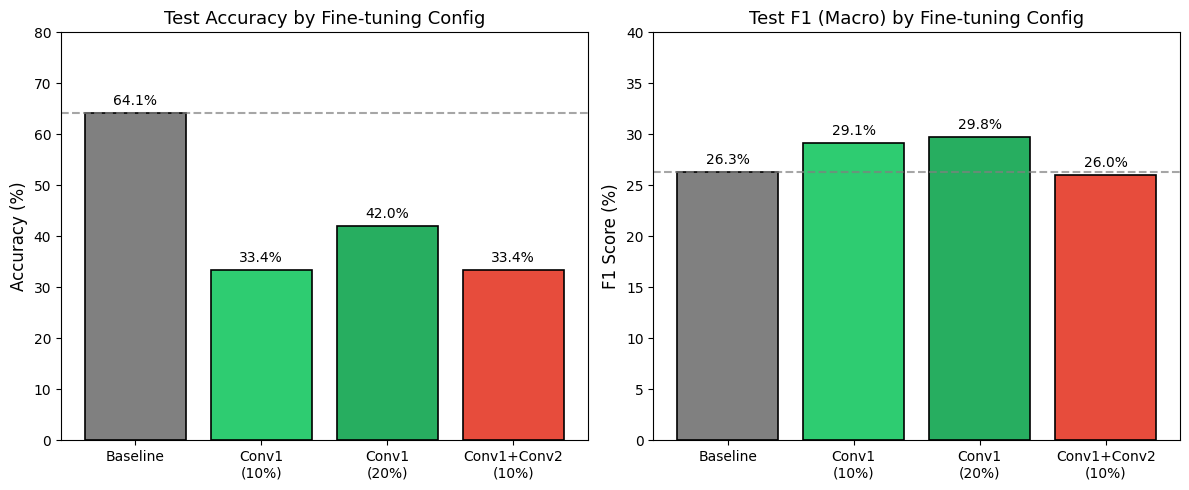

Saved: finetuning_results.png


In [25]:
import matplotlib.pyplot as plt

# PHASE 3D FINE-TUNING RESULTS VISUALIZATION
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

configs = ['Baseline', 'Conv1\n(10%)', 'Conv1\n(20%)', 'Conv1+Conv2\n(10%)']
accuracy = [64.08, 33.43, 42.05, 33.38]
f1_scores = [26.28, 29.13, 29.77, 26.01]
colors = ['#808080', '#2ecc71', '#27ae60', '#e74c3c']

# Accuracy plot
ax1 = axes[0]
bars1 = ax1.bar(configs, accuracy, color=colors, edgecolor='black', linewidth=1.2)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Test Accuracy by Fine-tuning Config', fontsize=13)
ax1.set_ylim(0, 80)
ax1.axhline(y=64.08, color='gray', linestyle='--', alpha=0.7)
for bar, val in zip(bars1, accuracy):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=10)

# F1 plot
ax2 = axes[1]
bars2 = ax2.bar(configs, f1_scores, color=colors, edgecolor='black', linewidth=1.2)
ax2.set_ylabel('F1 Score (%)', fontsize=12)
ax2.set_title('Test F1 (Macro) by Fine-tuning Config', fontsize=13)
ax2.set_ylim(0, 40)
ax2.axhline(y=26.28, color='gray', linestyle='--', alpha=0.7)
for bar, val in zip(bars2, f1_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('finetuning_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: finetuning_results.png")

Baseline prediction distribution: [     0 119434    651]
Actual label distribution: [22004 77327 20754]

Training Conv1 (20%) for prediction analysis...
  Trainable: 8,544 / 143,907 parameters (5.9%)


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\1943177332.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ft = torch.load('jupyter_pytorch/best_val_model_pytorch

    Epoch 1: Train Acc=45.29%, Val Acc=60.45%, Val F1=27.25%
    Epoch 5: Train Acc=47.75%, Val Acc=61.73%, Val F1=25.91%
    Early stopping at epoch 6
    Restoring best model from epoch 1 (Val F1=27.25%)


C:\Users\Ash\AppData\Local\Temp\ipykernel_22240\2943180960.py:113: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('temp_best_model.pt', map_l

Fine-tuned prediction distribution: [  2006 107162  10917]


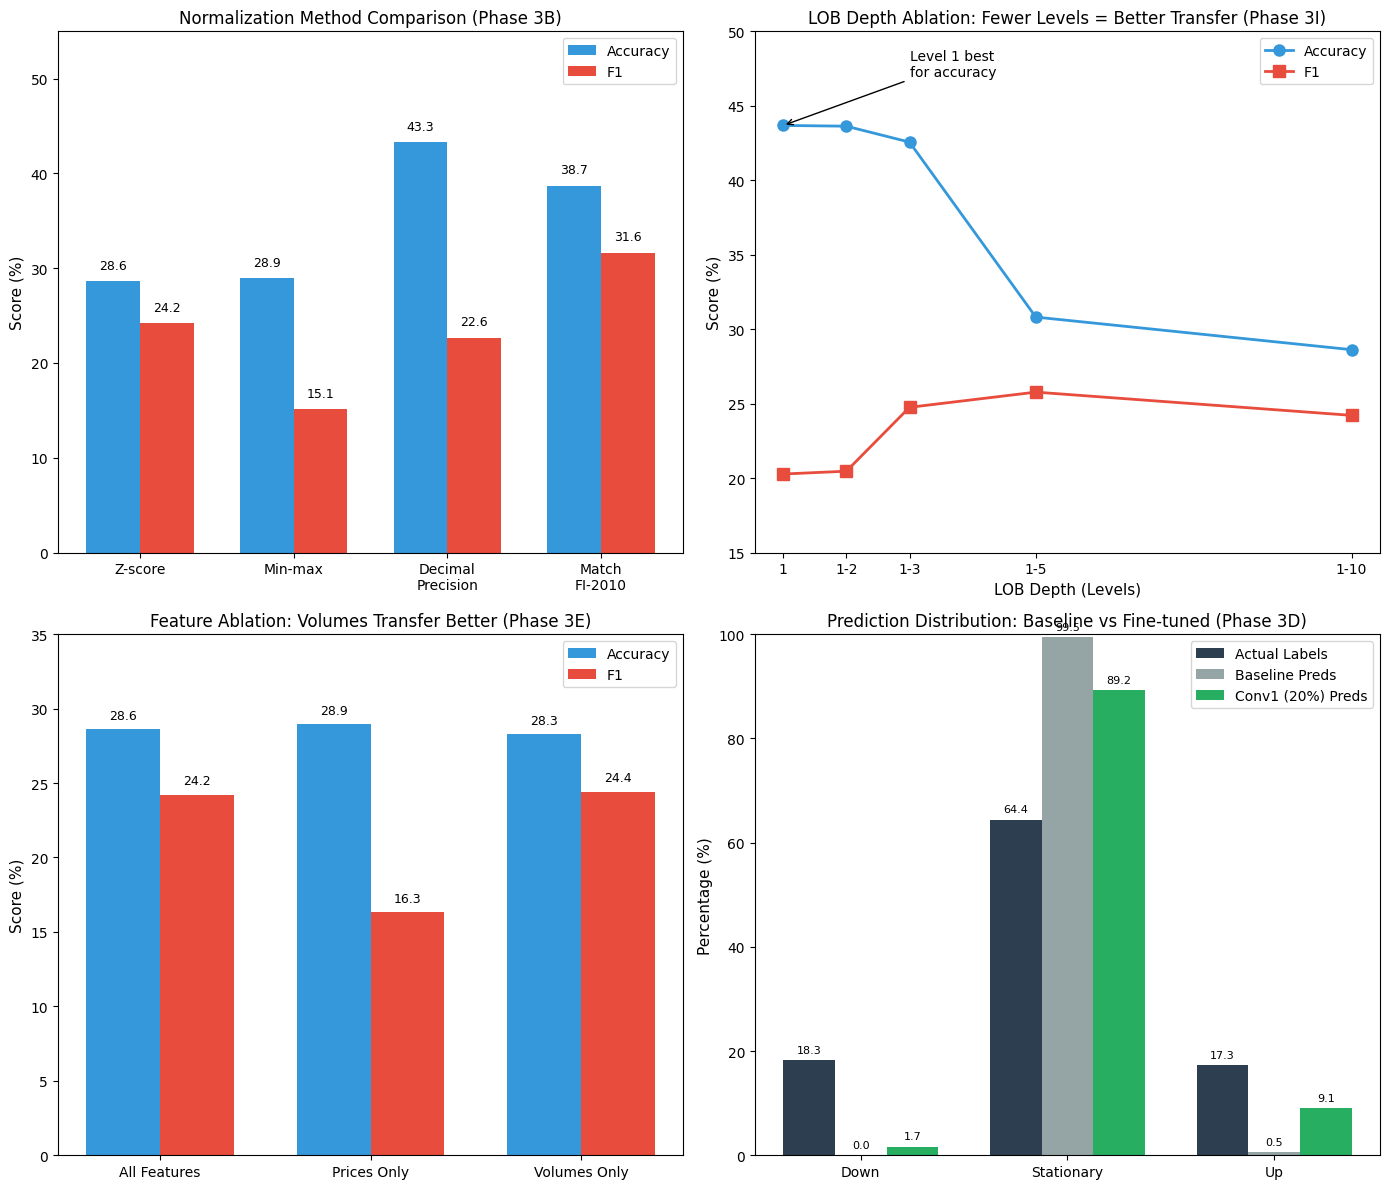


Saved: diagnostic_summary.png

Actual counts:
  Labels:    Down=22004, Stat=77327, Up=20754
  Baseline:  Down=0, Stat=119434, Up=651
  Fine-tuned: Down=2006, Stat=107162, Up=10917


In [26]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# FIRST: Get actual prediction counts for baseline and fine-tuned
# =============================================================================

# Baseline predictions
model.eval()
baseline_preds_list = []
baseline_labels_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        baseline_preds_list.extend(preds)
        baseline_labels_list.extend(y_batch.numpy())

baseline_pred_counts = np.bincount(baseline_preds_list, minlength=3)
actual_label_counts = np.bincount(baseline_labels_list, minlength=3)

print("Baseline prediction distribution:", baseline_pred_counts)
print("Actual label distribution:", actual_label_counts)

# Fine-tuned predictions (Conv1 20% - need to retrain or use saved)
print("\nTraining Conv1 (20%) for prediction analysis...")

model_ft = torch.load('jupyter_pytorch/best_val_model_pytorch', map_location=device)
model_ft.to(device)
frozen_modules = freeze_all_except(model_ft, ['conv1'])

train_end = int(len(X_all) * 0.20)
X_train = X_all[:train_end]
y_train = y_all[:train_end]

train_dataset = torch.utils.data.TensorDataset(
    torch.FloatTensor(X_train).unsqueeze(1),
    torch.LongTensor(y_train)
)
train_loader_ft = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

model_ft, _ = train_finetune(model_ft, train_loader_ft, val_loader, frozen_modules, epochs=20, lr=0.0001)

# Get fine-tuned predictions
model_ft.eval()
finetuned_preds_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model_ft(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        finetuned_preds_list.extend(preds)

finetuned_pred_counts = np.bincount(finetuned_preds_list, minlength=3)
print("Fine-tuned prediction distribution:", finetuned_pred_counts)

# =============================================================================
# NOW: Create all visualizations with verified data
# =============================================================================

fig_all, axes_all = plt.subplots(2, 2, figsize=(14, 12))

# =============================================================================
# 1. NORMALIZATION COMPARISON (Phase 3B)
# =============================================================================
ax1 = axes_all[0, 0]

norm_methods = ['Z-score', 'Min-max', 'Decimal\nPrecision', 'Match\nFI-2010']
norm_acc = [28.62, 28.93, 43.29, 38.70]
norm_f1 = [24.21, 15.11, 22.64, 31.62]

x = np.arange(len(norm_methods))
width = 0.35

bars1 = ax1.bar(x - width/2, norm_acc, width, label='Accuracy', color='#3498db')
bars2 = ax1.bar(x + width/2, norm_f1, width, label='F1', color='#e74c3c')

ax1.set_ylabel('Score (%)', fontsize=11)
ax1.set_title('Normalization Method Comparison (Phase 3B)', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels(norm_methods, fontsize=10)
ax1.legend()
ax1.set_ylim(0, 55)

# Add value labels
for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

# =============================================================================
# 2. LOB DEPTH ABLATION (Phase 3I)
# =============================================================================
ax2 = axes_all[0, 1]

depths = [1, 2, 3, 5, 10]
depth_acc = [43.68, 43.63, 42.56, 30.81, 28.62]
depth_f1 = [20.27, 20.46, 24.75, 25.77, 24.21]

ax2.plot(depths, depth_acc, 'o-', label='Accuracy', color='#3498db', linewidth=2, markersize=8)
ax2.plot(depths, depth_f1, 's-', label='F1', color='#e74c3c', linewidth=2, markersize=8)

ax2.set_xlabel('LOB Depth (Levels)', fontsize=11)
ax2.set_ylabel('Score (%)', fontsize=11)
ax2.set_title('LOB Depth Ablation: Fewer Levels = Better Transfer (Phase 3I)', fontsize=12)
ax2.set_xticks(depths)
ax2.set_xticklabels(['1', '1-2', '1-3', '1-5', '1-10'])
ax2.legend()
ax2.set_ylim(15, 50)

ax2.annotate('Level 1 best\nfor accuracy', xy=(1, 43.68), xytext=(3, 47),
             fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))

# =============================================================================
# 3. FEATURE IMPORTANCE (Phase 3E)
# =============================================================================
ax3 = axes_all[1, 0]

features = ['All Features', 'Prices Only', 'Volumes Only']
feat_acc = [28.62, 28.94, 28.26]
feat_f1 = [24.21, 16.33, 24.42]

x = np.arange(len(features))
bars3 = ax3.bar(x - width/2, feat_acc, width, label='Accuracy', color='#3498db')
bars4 = ax3.bar(x + width/2, feat_f1, width, label='F1', color='#e74c3c')

ax3.set_ylabel('Score (%)', fontsize=11)
ax3.set_title('Feature Ablation: Volumes Transfer Better (Phase 3E)', fontsize=12)
ax3.set_xticks(x)
ax3.set_xticklabels(features, fontsize=10)
ax3.legend()
ax3.set_ylim(0, 35)

# Add value labels
for bar in bars3:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars4:
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

# =============================================================================
# 4. PREDICTION DISTRIBUTION - ACTUAL DATA (Phase 3D)
# =============================================================================
ax4 = axes_all[1, 1]

classes = ['Down', 'Stationary', 'Up']
x = np.arange(len(classes))
width = 0.25

# Convert to percentages
total = len(baseline_preds_list)
baseline_pct = baseline_pred_counts / total * 100
finetuned_pct = finetuned_pred_counts / total * 100
actual_pct = actual_label_counts / total * 100

bars5 = ax4.bar(x - width, actual_pct, width, label='Actual Labels', color='#2c3e50')
bars6 = ax4.bar(x, baseline_pct, width, label='Baseline Preds', color='#95a5a6')
bars7 = ax4.bar(x + width, finetuned_pct, width, label='Conv1 (20%) Preds', color='#27ae60')

ax4.set_ylabel('Percentage (%)', fontsize=11)
ax4.set_title('Prediction Distribution: Baseline vs Fine-tuned (Phase 3D)', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(classes, fontsize=10)
ax4.legend()
ax4.set_ylim(0, 100)

# Add value labels
for bar in bars5:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars6:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)
for bar in bars7:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('diagnostic_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: diagnostic_summary.png")
print(f"\nActual counts:")
print(f"  Labels:    Down={actual_label_counts[0]}, Stat={actual_label_counts[1]}, Up={actual_label_counts[2]}")
print(f"  Baseline:  Down={baseline_pred_counts[0]}, Stat={baseline_pred_counts[1]}, Up={baseline_pred_counts[2]}")
print(f"  Fine-tuned: Down={finetuned_pred_counts[0]}, Stat={finetuned_pred_counts[1]}, Up={finetuned_pred_counts[2]}")